# Đồ án Học máy — SV16
## So sánh dự báo Flow giữa hai tập Sensor trong PeMSD3

**Nhóm 2** — Dữ liệu PeMSD (flow, speed, occupancy)

---

## 1. Cài đặt và nhập thư viện

### 1.1. Cài đặt thư viện

In [1]:
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Đọc danh sách packages từ requirements.txt
with open('requirements.txt', 'r') as f:
    required_packages = [line.strip() for line in f if line.strip() and not line.startswith('#')]

print("Đang kiểm tra và cài đặt các thư viện cần thiết...")
for package in required_packages:
    try:
        install_package(package)
        print(f"✅ {package} đã được cài đặt")
    except Exception as e:
        print(f"❌ Lỗi khi cài đặt {package}: {e}")

print(f"\nHoàn tất! Đã xử lý {len(required_packages)} packages.")

Đang kiểm tra và cài đặt các thư viện cần thiết...
✅ pandas>=2.0 đã được cài đặt
✅ numpy>=1.24 đã được cài đặt
✅ scikit-learn>=1.3 đã được cài đặt
✅ xgboost>=2.0 đã được cài đặt
✅ torch>=2.0 đã được cài đặt
✅ matplotlib>=3.7 đã được cài đặt
✅ seaborn>=0.12 đã được cài đặt
✅ plotly>=5.15 đã được cài đặt
✅ ipywidgets>=8.0 đã được cài đặt
✅ joblib đã được cài đặt
✅ pymoo>=0.6.0 đã được cài đặt

Hoàn tất! Đã xử lý 11 packages.


### 1.2. Nhập thư viện

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import modules của dự án
from modules import data_loader
from modules import eda
from modules import feature_engineering as fe
from modules import models
from modules import visualization as viz
from modules import comparison
from modules import stability

# Auto-reload modules khi chỉnh sửa code
%load_ext autoreload
%autoreload 2
%matplotlib inline

print('✅ Đã nhập tất cả thư viện thành công!')


✅ Đã nhập tất cả thư viện thành công!


---
## 2. Kiểm tra GPU

In [3]:
import torch

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device     : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')
else:
    print('⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)')

PyTorch version: 2.12.0+cpu
CUDA available : False
⚠️ Không có GPU — LSTM sẽ chạy trên CPU (chậm hơn)


---
## 3. Cấu hình (CONFIG)

**Tất cả thông số** có thể chỉnh sửa đều nằm ở đây.

In [4]:
from configs.configs import CONFIG

print('✅ CONFIG đã thiết lập')
print(f'   Baseline A sensors: {CONFIG["baseline_a_sensors"]}')
print(f'   Baseline B sensors: {CONFIG["baseline_b_sensors"]}')
print(f'   Split: Train {CONFIG["train_ratio"]*100:.0f}% / '
      f'Valid {CONFIG["valid_ratio"]*100:.0f}% / '
      f'Test {(1-CONFIG["train_ratio"]-CONFIG["valid_ratio"])*100:.0f}%')

✅ CONFIG đã thiết lập
   Baseline A sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010']
   Baseline B sensors: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Split: Train 70% / Valid 15% / Test 15%


---
## 4. Xử lý dữ liệu

### 4.1. Nhập dữ liệu

In [5]:
# Load dữ liệu gốc
df_raw = data_loader.load_raw_data(CONFIG['data_path'])

# Thông tin tổng quan
info = data_loader.get_data_info(df_raw)
data_loader.print_data_info(info)

✅ Đã load 48,384 dòng từ SV16_PeMSD3_sample_8sensors.csv
   Sensors: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010', 'PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014']
   Thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
📊 THÔNG TIN DATASET
  Tổng số dòng   : 48,384
  Số cột          : 6
  Số sensor       : 8
  Khoảng thời gian: 2024-02-01 00:00:00 → 2024-02-21 23:55:00
  Missing values  : 0

  Số dòng mỗi sensor:
    PEMSD3_007: 6,048 dòng
    PEMSD3_008: 6,048 dòng
    PEMSD3_009: 6,048 dòng
    PEMSD3_010: 6,048 dòng
    PEMSD3_011: 6,048 dòng
    PEMSD3_012: 6,048 dòng
    PEMSD3_013: 6,048 dòng
    PEMSD3_014: 6,048 dòng


In [6]:
# Xem 5 dòng đầu
df_raw.head()

,timestamp,sensor_id,flow,speed,occupancy,district
0,2024-02-01 00:00:00,PEMSD3_007,40.69,53.61,0.3019,D3
1,2024-02-01 00:05:00,PEMSD3_007,35.34,61.20,0.2259,D3
2,2024-02-01 00:10:00,PEMSD3_007,48.23,54.87,0.2803,D3
3,2024-02-01 00:15:00,PEMSD3_007,40.01,60.65,0.2086,D3
4,2024-02-01 00:20:00,PEMSD3_007,47.15,52.11,0.3292,D3


In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48384 entries, 0 to 48383
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  48384 non-null  datetime64[us]
 1   sensor_id  48384 non-null  str           
 2   flow       48384 non-null  float64       
 3   speed      48384 non-null  float64       
 4   occupancy  48384 non-null  float64       
 5   district   48384 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 2.2 MB


### 4.2. Thống kê mô tả & EDA

In [8]:
# Thống kê mô tả per sensor
stats = eda.describe_per_sensor(df_raw)
stats.T

sensor_id        PEMSD3_007  PEMSD3_008  PEMSD3_009  PEMSD3_010  PEMSD3_011  \
flow      count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        73.67       78.80       84.62       90.51       67.70   
          std         33.60       35.88       38.37       40.73       31.36   
          min          5.00        5.00        5.00       12.60        5.00   
          25%         47.04       50.17       54.27       58.01       43.02   
          50%         65.44       69.22       73.24       78.13       59.78   
          75%         99.02      105.42      114.11      122.19       90.94   
          max        174.09      188.52      218.03      207.37      172.89   
speed     count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean        51.80       50.90       49.80       48.66       52.86   
          std          6.74        7.01        7.50        7.93        6.39   
          min         29.20       26.01       24.20       22.82       30.01   
          25%         47.08       46.01       44.41       42.95       48.49   
          50%         52.73       52.06       51.12       50.16       53.62   
          75%         56.88       56.21       55.49       54.80       57.60   
          max         69.39       68.14       68.38       69.24       71.60   
occupancy count     6048.00     6048.00     6048.00     6048.00     6048.00   
          mean         0.44        0.47        0.50        0.53        0.40   
          std          0.20        0.21        0.22        0.23        0.19   
          min          0.02        0.02        0.04        0.04        0.02   
          25%          0.28        0.30        0.32        0.34        0.25   
          50%          0.39        0.41        0.44        0.47        0.36   
          75%          0.59        0.63        0.68        0.73        0.54   
          max          0.92        0.92        0.92        0.92        0.92   

sensor_id        PEMSD3_012  PEMSD3_013  PEMSD3_014  
flow      count     6048.00     6048.00     6048.00  
          mean        73.24       78.93       84.90  
          std         33.60       36.12       38.05  
          min          5.00        5.00       11.59  
          25%         46.61       50.17       54.75  
          50%         64.28       69.01       73.96  
          75%         98.63      106.52      113.83  
          max        170.33      189.50      193.02  
speed     count     6048.00     6048.00     6048.00  
          mean        51.83       50.81       49.80  
          std          6.76        7.14        7.48  
          min         31.24       26.90       27.38  
          25%         47.02       45.72       44.43  
          50%         52.80       51.96       51.11  
          75%         56.88       56.22       55.53  
          max         68.65       70.49       68.01  
occupancy count     6048.00     6048.00     6048.00  
          mean         0.43        0.47        0.50  
          std          0.20        0.21        0.22  
          min          0.03        0.02        0.06  
          25%          0.28        0.30        0.32  
          50%          0.38        0.41        0.44  
          75%          0.59        0.63        0.67  
          max          0.92        0.92        0.92

In [9]:
# Kiểm tra missing data
missing_report = eda.check_missing(df_raw)
missing_report

,sensor_id,n_rows,n_null_values,missing_rate_%,n_time_gaps
0,PEMSD3_007,6048,0,0.0,0
1,PEMSD3_008,6048,0,0.0,0
2,PEMSD3_009,6048,0,0.0,0
3,PEMSD3_010,6048,0,0.0,0
4,PEMSD3_011,6048,0,0.0,0
5,PEMSD3_012,6048,0,0.0,0
6,PEMSD3_013,6048,0,0.0,0
7,PEMSD3_014,6048,0,0.0,0


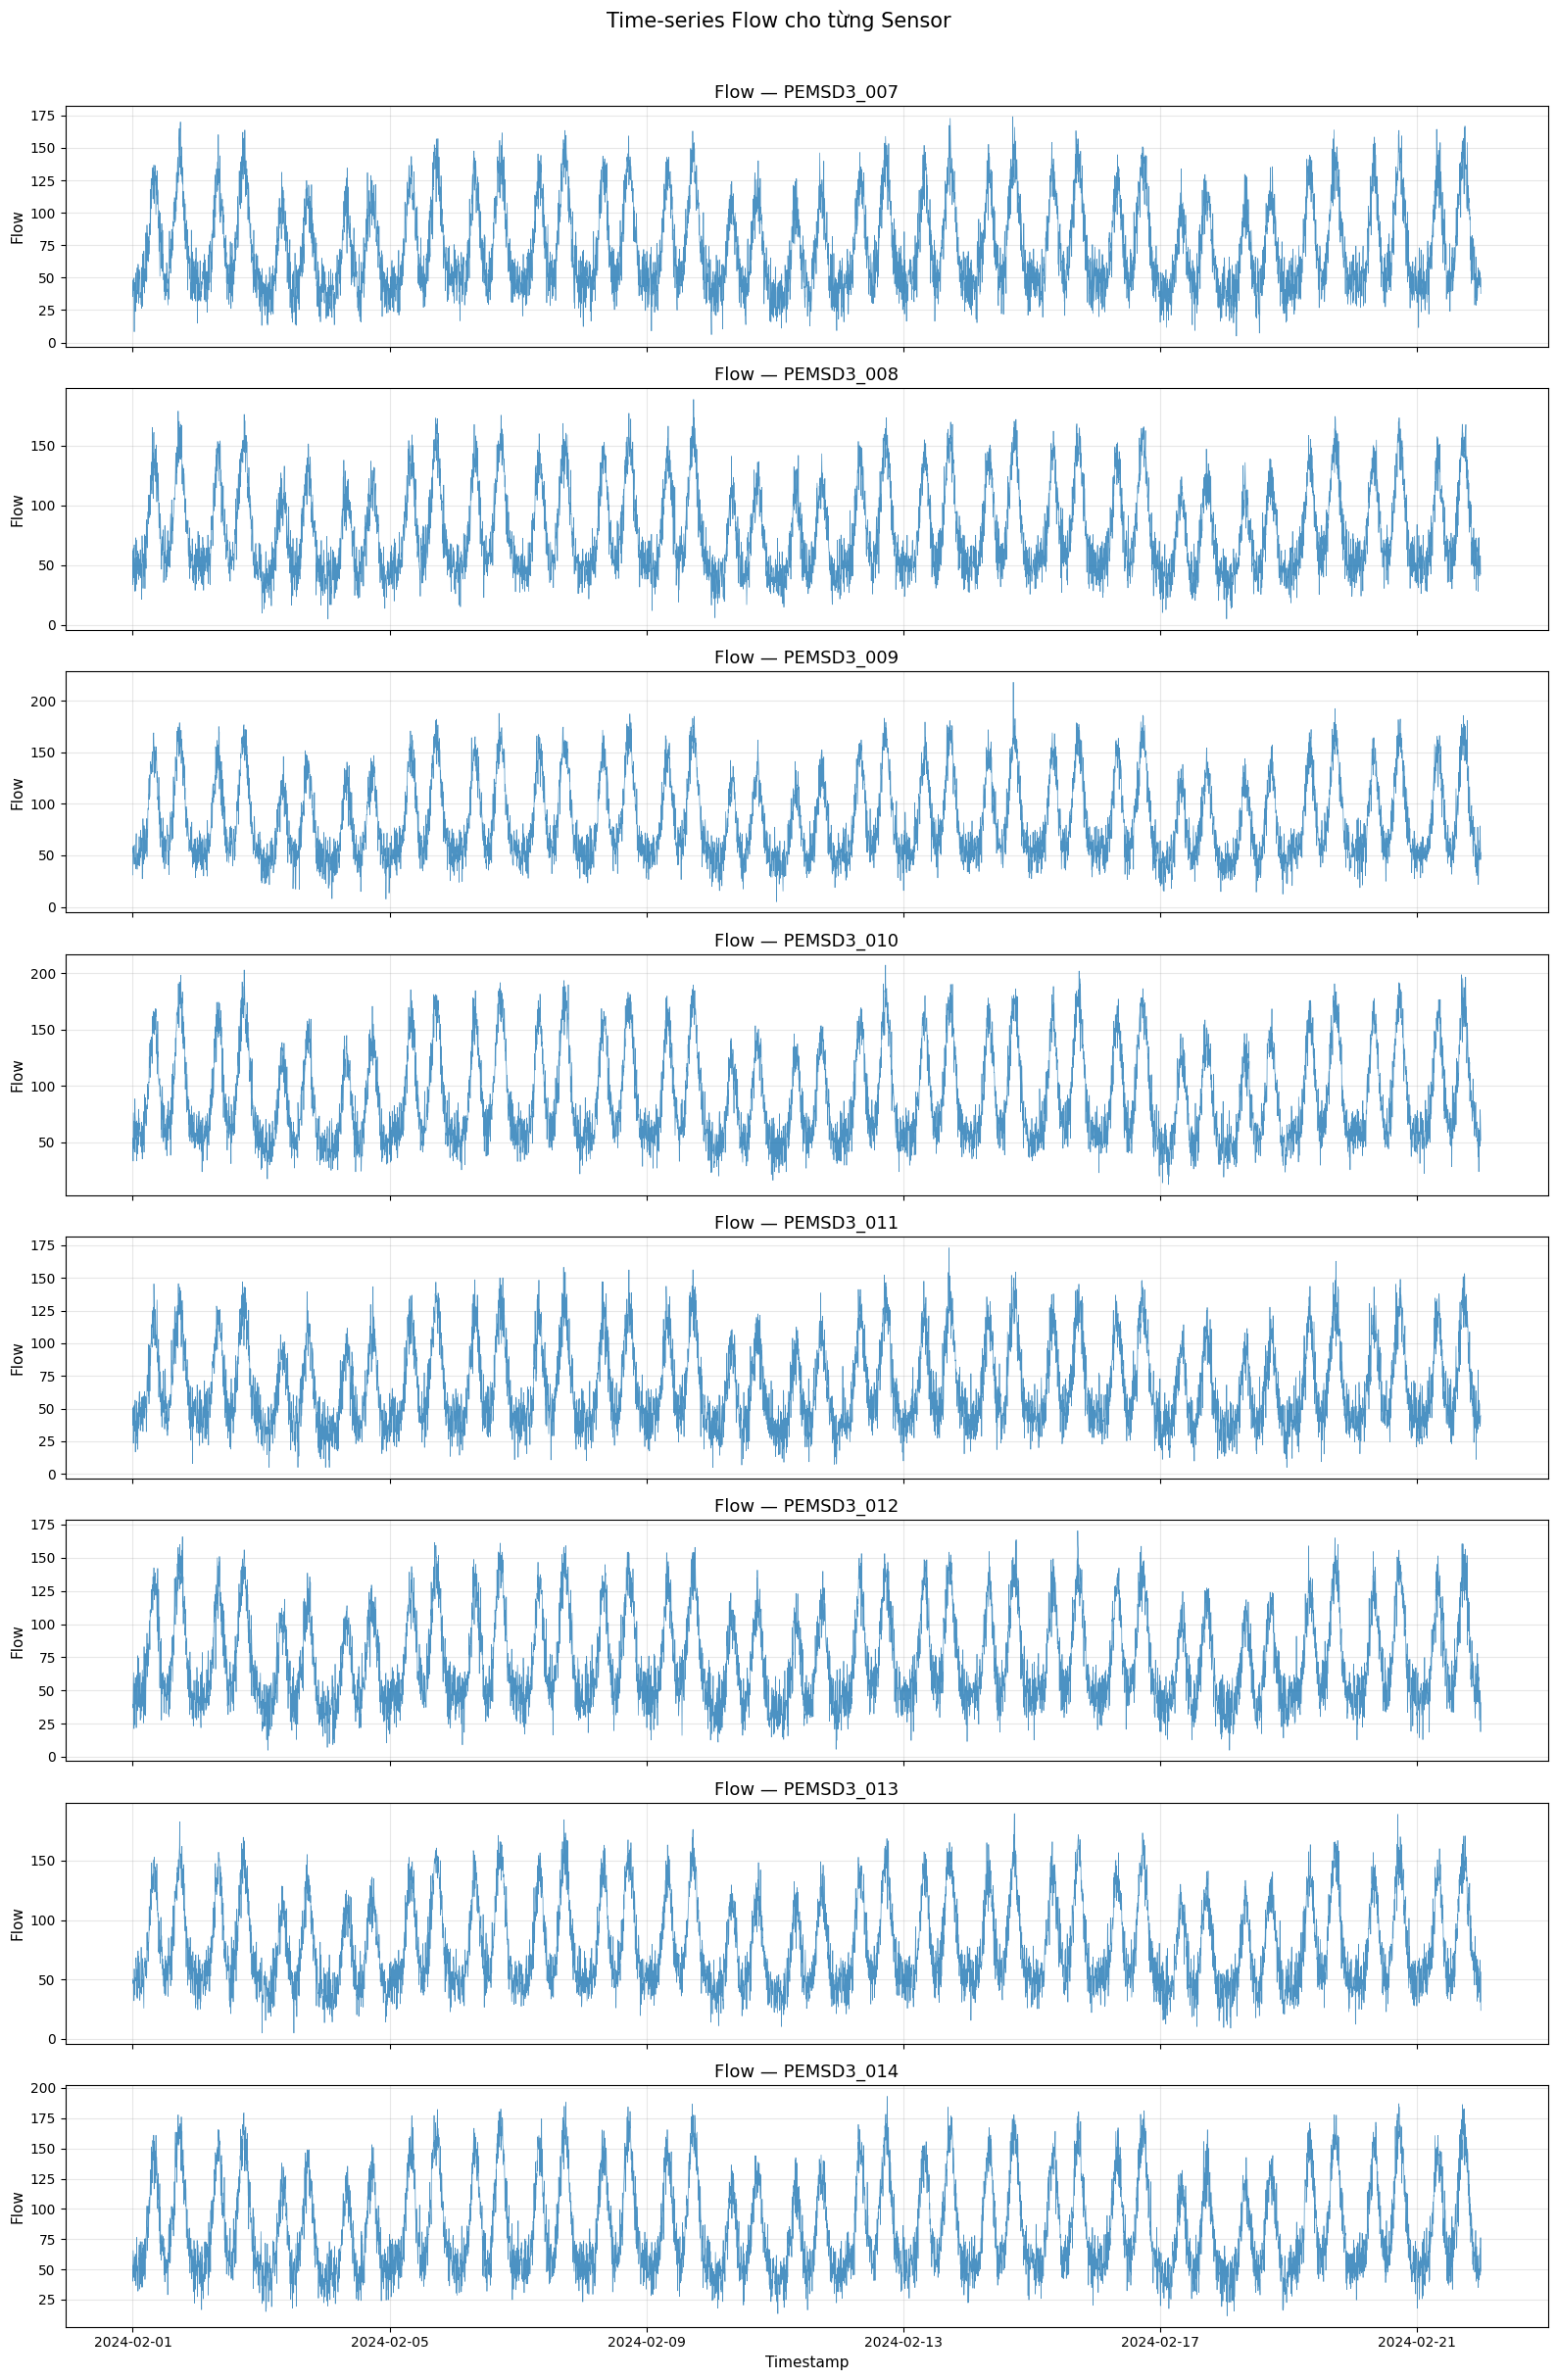

In [10]:
# Biểu đồ time-series flow cho từng sensor
eda.plot_timeseries_flow(df_raw, save_dir=CONFIG['images_dir'])

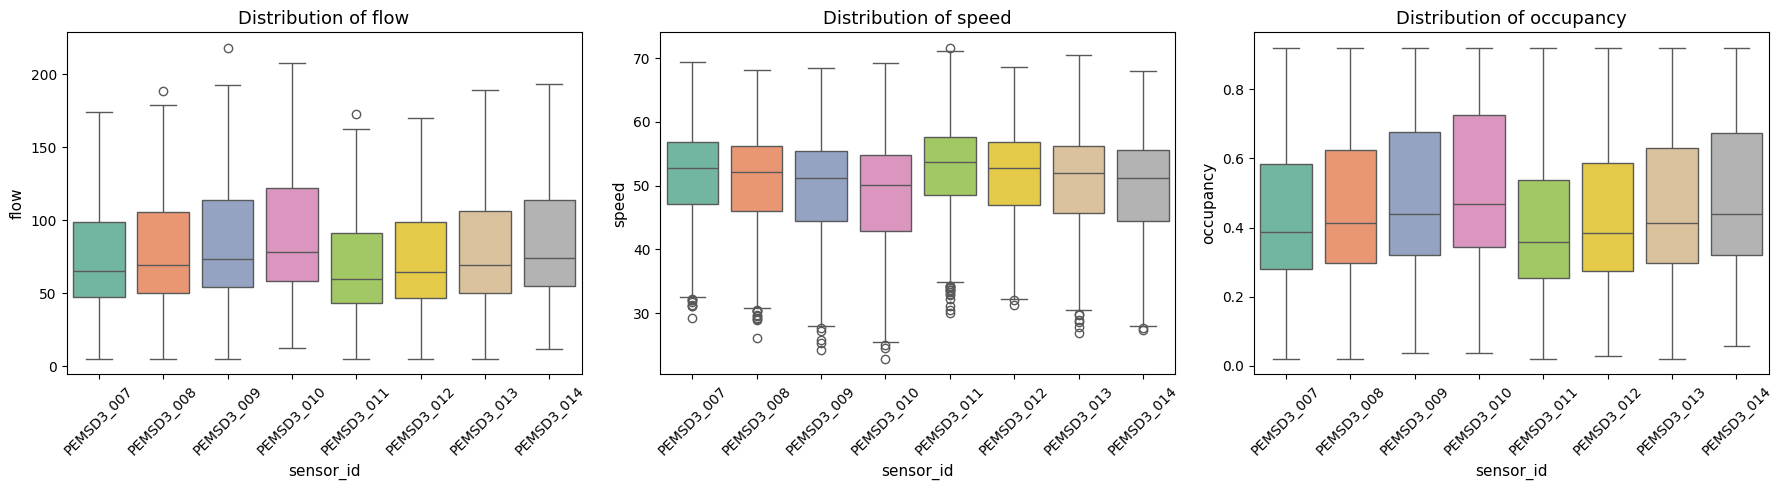

In [11]:
# Distribution boxplot
eda.plot_distribution(df_raw, save_dir=CONFIG['images_dir'])

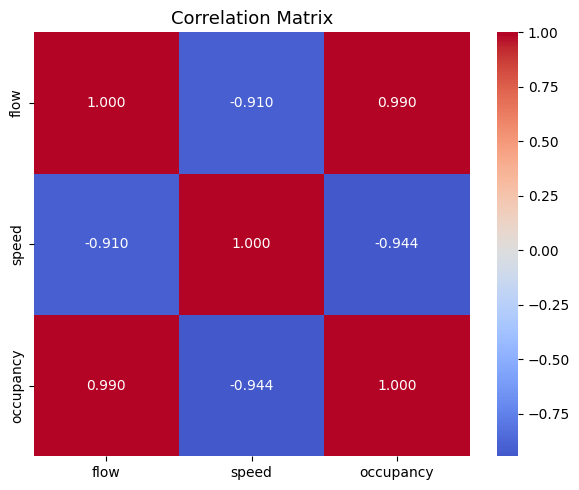

In [12]:
# Correlation heatmap
eda.plot_correlation(df_raw, save_dir=CONFIG['images_dir'])

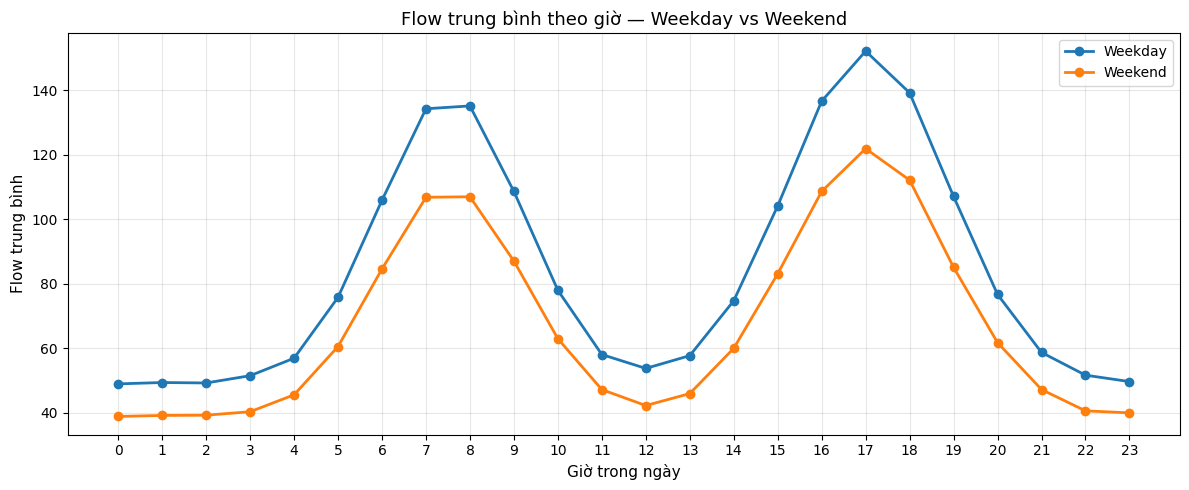

In [13]:
# Hourly pattern: Weekday vs Weekend
eda.plot_hourly_pattern(df_raw, save_dir=CONFIG['images_dir'])

### 4.3. Feature Engineering

In [14]:
# Tạo toàn bộ features: time + lag + rolling + target
df_featured = fe.prepare_all_features(df_raw, CONFIG)

# Kiểm tra kết quả
print(f'\nShape sau feature engineering: {df_featured.shape}')
print(f'Columns: {list(df_featured.columns)}')
df_featured.head()

✅ Đã thêm time features: hour, weekday, is_weekend, time_slot
✅ Đã thêm 15 lag features (lags=[1, 2, 3, 6, 12], cols=['flow', 'speed', 'occupancy'])
✅ Đã thêm 18 rolling features (windows=[3, 6, 12])
✅ Đã tạo target: flow_target (t+3 = 15 phút)
✅ Drop NaN: 48,384 → 48,264 dòng (mất 120)

Shape sau feature engineering: (48264, 44)
Columns: ['timestamp', 'sensor_id', 'flow', 'speed', 'occupancy', 'district', 'hour', 'weekday', 'is_weekend', 'time_slot', 'flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'flow_lag_6', 'flow_lag_12', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'occupancy_lag_6', 'occupancy_lag_12', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'occupancy_roll_mean_3', 'occupancy_roll_std_3', 'occupan

,timestamp,sensor_id,flow,speed,occupancy,district,hour,weekday,is_weekend,time_slot,...,speed_roll_std_6,speed_roll_mean_12,speed_roll_std_12,occupancy_roll_mean_3,occupancy_roll_std_3,occupancy_roll_mean_6,occupancy_roll_std_6,occupancy_roll_mean_12,occupancy_roll_std_12,flow_target
0,2024-02-01 01:00:00,PEMSD3_007,23.97,65.17,0.1349,D3,1,3,0,0,...,3.554916,58.032500,4.257511,0.203433,0.063798,0.205117,0.083202,0.241242,0.079233,31.66
1,2024-02-01 01:05:00,PEMSD3_007,53.57,54.47,0.3182,D3,1,3,0,0,...,3.881698,57.471667,4.245579,0.222467,0.091922,0.244450,0.067838,0.248933,0.082038,37.94
2,2024-02-01 01:10:00,PEMSD3_007,35.17,57.18,0.2031,D3,1,3,0,0,...,3.538226,57.664167,4.168563,0.218733,0.092645,0.226817,0.061156,0.242500,0.082381,39.75
3,2024-02-01 01:15:00,PEMSD3_007,31.66,59.90,0.1457,D3,1,3,0,0,...,3.561887,57.601667,4.125122,0.222333,0.087844,0.212883,0.069439,0.237258,0.086626,30.82
4,2024-02-01 01:20:00,PEMSD3_007,37.94,55.18,0.2483,D3,1,3,0,0,...,3.887002,57.857500,3.838840,0.199033,0.051421,0.210750,0.067840,0.230517,0.081836,49.88


In [15]:
# Danh sách feature columns sẽ dùng cho modeling
FEATURE_COLS = fe.get_feature_columns(CONFIG)
TARGET_COL = 'flow_target'

print(f'Số features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')

Số features: 36
Features: ['flow_lag_1', 'flow_lag_2', 'flow_lag_3', 'flow_lag_6', 'flow_lag_12', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'occupancy_lag_1', 'occupancy_lag_2', 'occupancy_lag_3', 'occupancy_lag_6', 'occupancy_lag_12', 'flow_roll_mean_3', 'flow_roll_std_3', 'flow_roll_mean_6', 'flow_roll_std_6', 'flow_roll_mean_12', 'flow_roll_std_12', 'speed_roll_mean_3', 'speed_roll_std_3', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_roll_std_12', 'occupancy_roll_mean_3', 'occupancy_roll_std_3', 'occupancy_roll_mean_6', 'occupancy_roll_std_6', 'occupancy_roll_mean_12', 'occupancy_roll_std_12', 'hour', 'weekday', 'is_weekend']
Target: flow_target


### 4.4. Chia Baseline A & Baseline B

In [16]:
df_baseline_a, df_baseline_b = data_loader.split_baselines(
    df_featured,
    CONFIG['baseline_a_sensors'],
    CONFIG['baseline_b_sensors'],
)

✅ Chia Baselines:
   Baseline A: ['PEMSD3_007', 'PEMSD3_008', 'PEMSD3_009', 'PEMSD3_010'] → 24,132 dòng
   Baseline B: ['PEMSD3_011', 'PEMSD3_012', 'PEMSD3_013', 'PEMSD3_014'] → 24,132 dòng


### 4.5. Hold-out Split (Train 70% / Valid 15% / Test 15%)

In [17]:
# Baseline A
print('── Baseline A ──')
train_a, valid_a, test_a = fe.holdout_split(
    df_baseline_a, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

# Baseline B
print('\n── Baseline B ──')
train_b, valid_b, test_b = fe.holdout_split(
    df_baseline_b, CONFIG['train_ratio'], CONFIG['valid_ratio']
)

── Baseline A ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,892 dòng (70%)
   Valid : 3,620 dòng (15%)
   Test  : 3,620 dòng (15%)

── Baseline B ──
✅ Hold-out Split (theo thời gian, per sensor):
   Train : 16,892 dòng (70%)
   Valid : 3,620 dòng (15%)
   Test  : 3,620 dòng (15%)


In [18]:
# Chuẩn bị X, y cho modeling
X_train_a, y_train_a = train_a[FEATURE_COLS].values, train_a[TARGET_COL].values
X_valid_a, y_valid_a = valid_a[FEATURE_COLS].values, valid_a[TARGET_COL].values
X_test_a,  y_test_a  = test_a[FEATURE_COLS].values,  test_a[TARGET_COL].values

X_train_b, y_train_b = train_b[FEATURE_COLS].values, train_b[TARGET_COL].values
X_valid_b, y_valid_b = valid_b[FEATURE_COLS].values, valid_b[TARGET_COL].values
X_test_b,  y_test_b  = test_b[FEATURE_COLS].values,  test_b[TARGET_COL].values

print(f'Baseline A — X_train: {X_train_a.shape}, X_valid: {X_valid_a.shape}, X_test: {X_test_a.shape}')
print(f'Baseline B — X_train: {X_train_b.shape}, X_valid: {X_valid_b.shape}, X_test: {X_test_b.shape}')

Baseline A — X_train: (16892, 36), X_valid: (3620, 36), X_test: (3620, 36)
Baseline B — X_train: (16892, 36), X_valid: (3620, 36), X_test: (3620, 36)


In [19]:
# Lưu datasets đã xử lý (tuỳ chọn)
import os
os.makedirs(CONFIG['clean_dir'], exist_ok=True)

train_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_train.csv", index=False)
valid_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_valid.csv", index=False)
test_a.to_csv(f"{CONFIG['clean_dir']}/baselineA_test.csv", index=False)
train_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_train.csv", index=False)
valid_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_valid.csv", index=False)
test_b.to_csv(f"{CONFIG['clean_dir']}/baselineB_test.csv", index=False)

print(f'✅ Đã lưu datasets vào {CONFIG["clean_dir"]}/')

✅ Đã lưu datasets vào __datasets-clean/


---
## 5. Xây dựng mô hình Baseline

Huấn luyện **10 mô hình** (3 trivial baselines + 7 ML) cho mỗi baseline:
1. Linear Regression
2. Ridge Regression
3. KNN Regressor
4. Decision Tree Regressor
5. Random Forest Regressor
6. XGBoost Regressor
4. Decision Tree Regressor\n",
    "5. Random Forest Regressor\n",
    "6. XGBoost Regressor\n",
    "7. LSTM

### 5.1. Huấn luyện 10 mô hình cho Baseline A

In [20]:
models_a = models.get_models(CONFIG)
results_a, trained_a = models.train_and_evaluate(
    models_a, X_train_a, y_train_a,
    X_valid_a, y_valid_a,
    X_test_a, y_test_a,
    baseline_name='Baseline_A'
)
results_a


🚀 HUẤN LUYỆN Baseline_A — 10 mô hình

--- 0a_SeasonalNaive ---
   Train — MAE=24.05  RMSE=29.67  R²=0.3809  MASE=1.7561
   Valid — MAE=23.14  RMSE=28.32  R²=0.3980  MASE=1.6894
   Test  — MAE=24.89  RMSE=30.42  R²=0.3902  MASE=1.8171
   ⏱ Thời gian huấn luyện: 0.000s

--- 0b_DriftMethod ---
   Train — MAE=14.50  RMSE=18.19  R²=0.7673  MASE=1.0582
   Valid — MAE=14.52  RMSE=18.10  R²=0.7540  MASE=1.0598
   Test  — MAE=14.73  RMSE=18.48  R²=0.7750  MASE=1.0752
   ⏱ Thời gian huấn luyện: 0.001s

--- 0c_SMA ---
   Train — MAE=15.13  RMSE=18.75  R²=0.7527  MASE=1.1049
   Valid — MAE=14.48  RMSE=18.00  R²=0.7568  MASE=1.0573
   Test  — MAE=15.51  RMSE=19.07  R²=0.7603  MASE=1.1325
   ⏱ Thời gian huấn luyện: 0.000s

--- 1_LinearRegression ---
   Train — MAE=11.41  RMSE=14.28  R²=0.8566  MASE=0.8332
   Valid — MAE=11.41  RMSE=14.23  R²=0.8480  MASE=0.8329
   Test  — MAE=11.41  RMSE=14.28  R²=0.8657  MASE=0.8331
   ⏱ Thời gian huấn luyện: 0.274s

--- 2_Ridge ---
   Train — MAE=11.42  RMSE=14.2

,model,baseline,train_time_s,train_MAE,train_RMSE,train_MAPE,train_R2,train_MASE,valid_MAE,valid_RMSE,valid_MAPE,valid_R2,valid_MASE,test_MAE,test_RMSE,test_MAPE,test_R2,test_MASE
0,5_RandomForest,Baseline_A,13.752,5.5352,6.8738,9.2741,0.9668,0.4041,10.5536,13.2111,18.6125,0.8690,0.7704,10.3849,13.0622,15.5648,0.8876,0.7581
1,6_XGBoost,Baseline_A,9.642,4.3002,5.6472,6.7944,0.9776,0.3139,10.4520,13.1215,18.4215,0.8707,0.7630,10.5081,13.2118,15.7194,0.8850,0.7671
2,7_LSTM,Baseline_A,80.607,10.7012,13.4423,17.1131,0.8729,0.7812,10.9249,13.6852,19.0629,0.8594,0.7976,10.7753,13.5810,16.0121,0.8785,0.7866
3,3_KNN,Baseline_A,0.003,0.0000,0.0000,0.0000,1.0000,0.0000,11.4049,14.3594,20.3122,0.8452,0.8326,11.1509,14.0142,16.5389,0.8706,0.8141
4,1_LinearRegression,Baseline_A,0.274,11.4132,14.2807,18.4205,0.8566,0.8332,11.4087,14.2274,20.1422,0.8480,0.8329,11.4111,14.2762,17.2474,0.8657,0.8331
5,2_Ridge,Baseline_A,0.098,11.4152,14.2823,18.4222,0.8566,0.8334,11.4042,14.2251,20.1421,0.8481,0.8325,11.4141,14.2800,17.2441,0.8656,0.8333
6,4_DecisionTree,Baseline_A,3.092,3.8568,6.3965,6.5708,0.9712,0.2816,14.0786,17.8096,23.7846,0.7619,1.0278,13.7375,17.4033,20.0445,0.8004,1.0029
7,0b_DriftMethod,Baseline_A,0.001,14.4954,18.1913,22.3153,0.7673,1.0582,14.5176,18.1032,24.3553,0.7540,1.0598,14.7282,18.4780,21.3326,0.7750,1.0752
8,0c_SMA,Baseline_A,0.000,15.1345,18.7538,21.9844,0.7527,1.1049,14.4822,17.9973,23.1991,0.7568,1.0573,15.5128,19.0732,21.1267,0.7603,1.1325
9,0a_SeasonalNaive,Baseline_A,0.000,24.0548,29.6735,33.5016,0.3809,1.7561,23.1410,28.3171,35.3397,0.3980,1.6894,24.8910,30.4216,32.8822,0.3902,1.8171


### 5.2. Huấn luyện 10 mô hình cho Baseline B

In [21]:
models_b = models.get_models(CONFIG)
results_b, trained_b = models.train_and_evaluate(
    models_b, X_train_b, y_train_b,
    X_valid_b, y_valid_b,
    X_test_b, y_test_b,
    baseline_name='Baseline_B'
)
results_b


🚀 HUẤN LUYỆN Baseline_B — 10 mô hình

--- 0a_SeasonalNaive ---
   Train — MAE=22.92  RMSE=28.30  R²=0.3624  MASE=1.6848
   Valid — MAE=21.78  RMSE=26.80  R²=0.3746  MASE=1.6010
   Test  — MAE=23.64  RMSE=29.14  R²=0.3735  MASE=1.7378
   ⏱ Thời gian huấn luyện: 0.000s

--- 0b_DriftMethod ---
   Train — MAE=14.38  RMSE=18.03  R²=0.7412  MASE=1.0575
   Valid — MAE=14.22  RMSE=17.85  R²=0.7226  MASE=1.0458
   Test  — MAE=14.34  RMSE=18.05  R²=0.7598  MASE=1.0541
   ⏱ Thời gian huấn luyện: 0.001s

--- 0c_SMA ---
   Train — MAE=14.49  RMSE=17.98  R²=0.7428  MASE=1.0654
   Valid — MAE=13.96  RMSE=17.26  R²=0.7406  MASE=1.0263
   Test  — MAE=14.90  RMSE=18.42  R²=0.7499  MASE=1.0956
   ⏱ Thời gian huấn luyện: 0.001s

--- 1_LinearRegression ---
   Train — MAE=11.23  RMSE=14.12  R²=0.8413  MASE=0.8256
   Valid — MAE=11.18  RMSE=14.03  R²=0.8286  MASE=0.8216
   Test  — MAE=11.53  RMSE=14.35  R²=0.8480  MASE=0.8480
   ⏱ Thời gian huấn luyện: 0.038s

--- 2_Ridge ---
   Train — MAE=11.23  RMSE=14.1

,model,baseline,train_time_s,train_MAE,train_RMSE,train_MAPE,train_R2,train_MASE,valid_MAE,valid_RMSE,valid_MAPE,valid_R2,valid_MASE,test_MAE,test_RMSE,test_MAPE,test_R2,test_MASE
0,6_XGBoost,Baseline_B,3.304,4.4550,5.8606,7.8425,0.9727,0.3275,10.4263,13.0923,19.5388,0.8508,0.7665,10.6180,13.3665,17.8084,0.8682,0.7806
1,5_RandomForest,Baseline_B,10.393,5.5524,6.8787,10.1844,0.9623,0.4082,10.4539,13.0886,19.6553,0.8508,0.7685,10.6383,13.3811,17.8712,0.8679,0.7821
2,7_LSTM,Baseline_B,62.513,10.5927,13.3223,18.5725,0.8587,0.7787,10.6700,13.4079,19.9439,0.8435,0.7844,10.9900,13.8032,18.2593,0.8595,0.8080
3,1_LinearRegression,Baseline_B,0.038,11.2304,14.1198,19.8514,0.8413,0.8256,11.1761,14.0316,21.1376,0.8286,0.8216,11.5343,14.3542,19.3927,0.8480,0.8480
4,2_Ridge,Baseline_B,0.013,11.2315,14.1203,19.8540,0.8413,0.8257,11.1782,14.0337,21.1398,0.8285,0.8218,11.5353,14.3548,19.3929,0.8480,0.8480
5,3_KNN,Baseline_B,0.010,0.0000,0.0000,0.0000,1.0000,0.0000,11.3152,14.2745,21.3287,0.8226,0.8319,11.4326,14.4237,19.1434,0.8466,0.8405
6,4_DecisionTree,Baseline_B,1.101,4.2994,6.9179,7.9706,0.9619,0.3161,13.7244,17.3516,24.7309,0.7379,1.0090,13.8130,17.4536,22.0495,0.7753,1.0155
7,0b_DriftMethod,Baseline_B,0.001,14.3844,18.0305,24.4070,0.7412,1.0575,14.2248,17.8508,25.7974,0.7226,1.0458,14.3388,18.0452,23.2295,0.7598,1.0541
8,0c_SMA,Baseline_B,0.001,14.4921,17.9754,23.2301,0.7428,1.0654,13.9595,17.2609,24.1345,0.7406,1.0263,14.9027,18.4151,22.8314,0.7499,1.0956
9,0a_SeasonalNaive,Baseline_B,0.000,22.9176,28.3014,35.1581,0.3624,1.6848,21.7774,26.8003,35.8074,0.3746,1.6010,23.6375,29.1442,35.0244,0.3735,1.7378


### 5.3. Lưu mô hình

In [22]:
models.save_models(trained_a, CONFIG['models_dir'], 'Baseline_A')
models.save_models(trained_b, CONFIG['models_dir'], 'Baseline_B')

✅ Đã lưu 10 mô hình vào models\Baseline_A
✅ Đã lưu 10 mô hình vào models\Baseline_B


### 5.4. Biểu đồ Actual vs Predicted — Baseline A

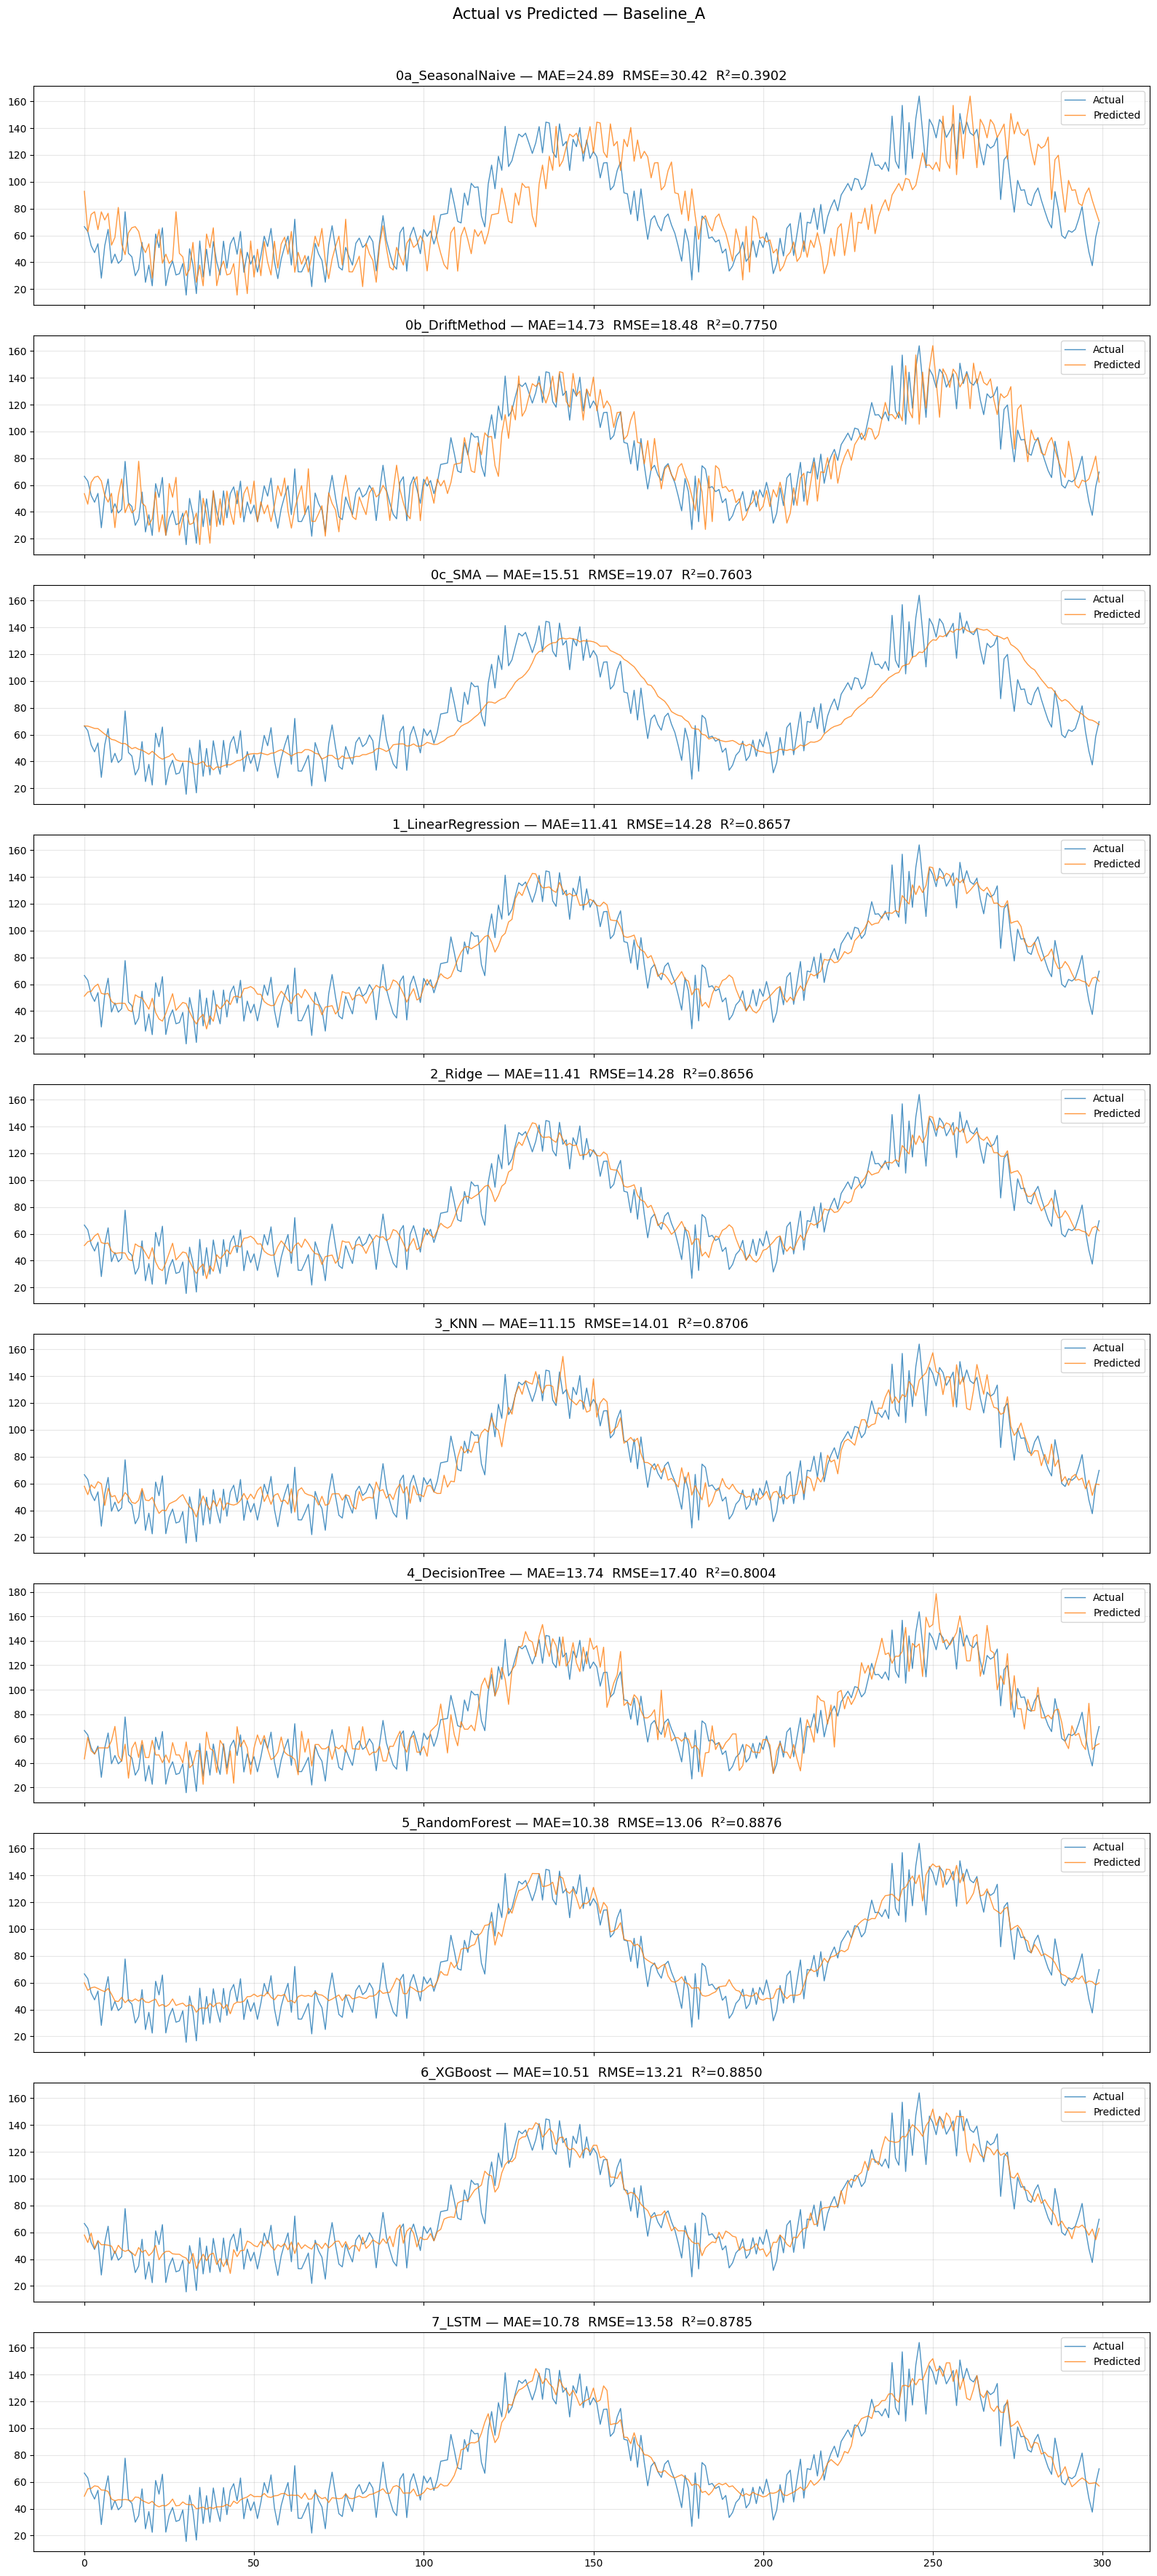

In [23]:
viz.plot_all_model_results(
    trained_a, y_test_a,
    baseline_name='Baseline_A',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

### 5.5. Biểu đồ Actual vs Predicted — Baseline B

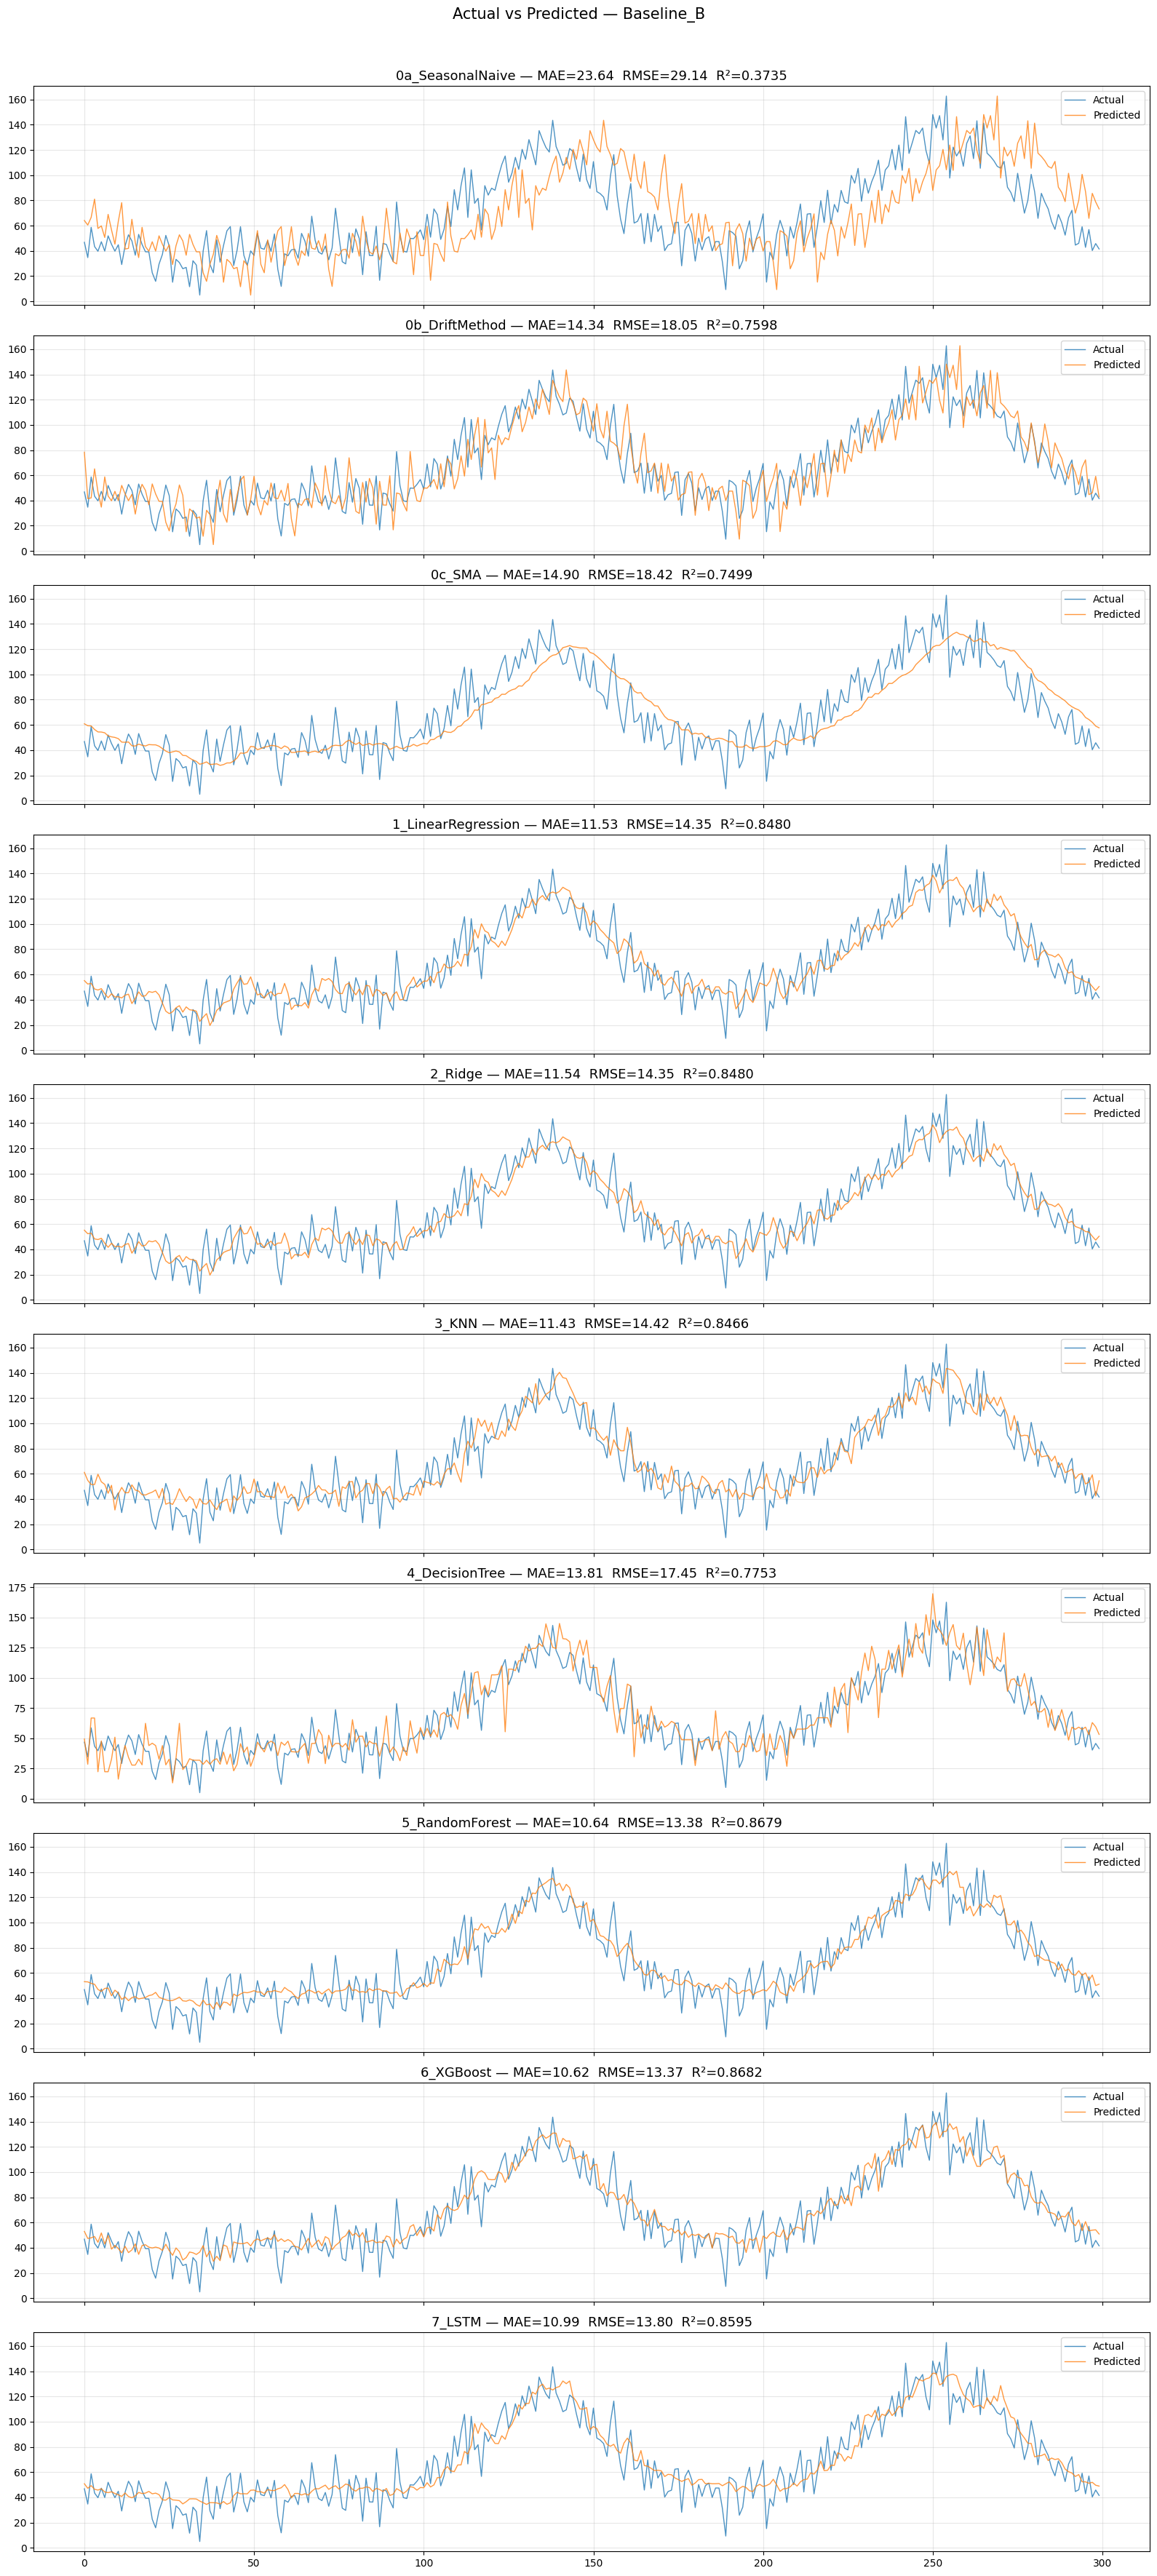

In [24]:
viz.plot_all_model_results(
    trained_b, y_test_b,
    baseline_name='Baseline_B',
    save_dir=CONFIG['images_dir'],
    n_points=300
)

---
## 6. So sánh 2 Baseline

### 6.1. Bảng tổng hợp metrics

In [25]:
compare_table = comparison.create_comparison_table(results_a, results_b)
compare_table

,model,A_MAE,B_MAE,A_RMSE,B_RMSE,A_MAPE,B_MAPE,A_R2,B_R2,A_MASE,B_MASE,better
0,5_RandomForest,10.3849,10.6383,13.0622,13.3811,15.5648,17.8712,0.8876,0.8679,0.7581,0.7821,A
1,6_XGBoost,10.5081,10.6180,13.2118,13.3665,15.7194,17.8084,0.8850,0.8682,0.7671,0.7806,A
2,7_LSTM,10.7753,10.9900,13.5810,13.8032,16.0121,18.2593,0.8785,0.8595,0.7866,0.8080,A
3,3_KNN,11.1509,11.4326,14.0142,14.4237,16.5389,19.1434,0.8706,0.8466,0.8141,0.8405,A
4,1_LinearRegression,11.4111,11.5343,14.2762,14.3542,17.2474,19.3927,0.8657,0.8480,0.8331,0.8480,A
5,2_Ridge,11.4141,11.5353,14.2800,14.3548,17.2441,19.3929,0.8656,0.8480,0.8333,0.8480,A
6,4_DecisionTree,13.7375,13.8130,17.4033,17.4536,20.0445,22.0495,0.8004,0.7753,1.0029,1.0155,A
7,0b_DriftMethod,14.7282,14.3388,18.4780,18.0452,21.3326,23.2295,0.7750,0.7598,1.0752,1.0541,B
8,0c_SMA,15.5128,14.9027,19.0732,18.4151,21.1267,22.8314,0.7603,0.7499,1.1325,1.0956,B
9,0a_SeasonalNaive,24.8910,23.6375,30.4216,29.1442,32.8822,35.0244,0.3902,0.3735,1.8171,1.7378,B


### 6.2. Biểu đồ so sánh

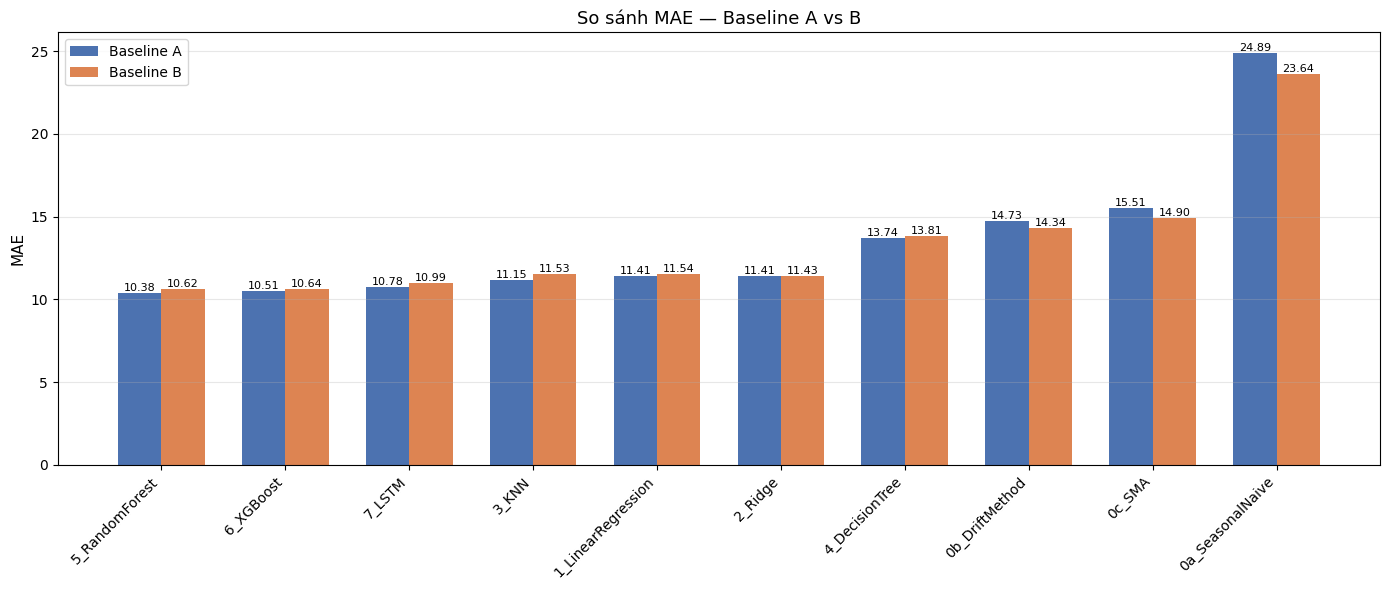

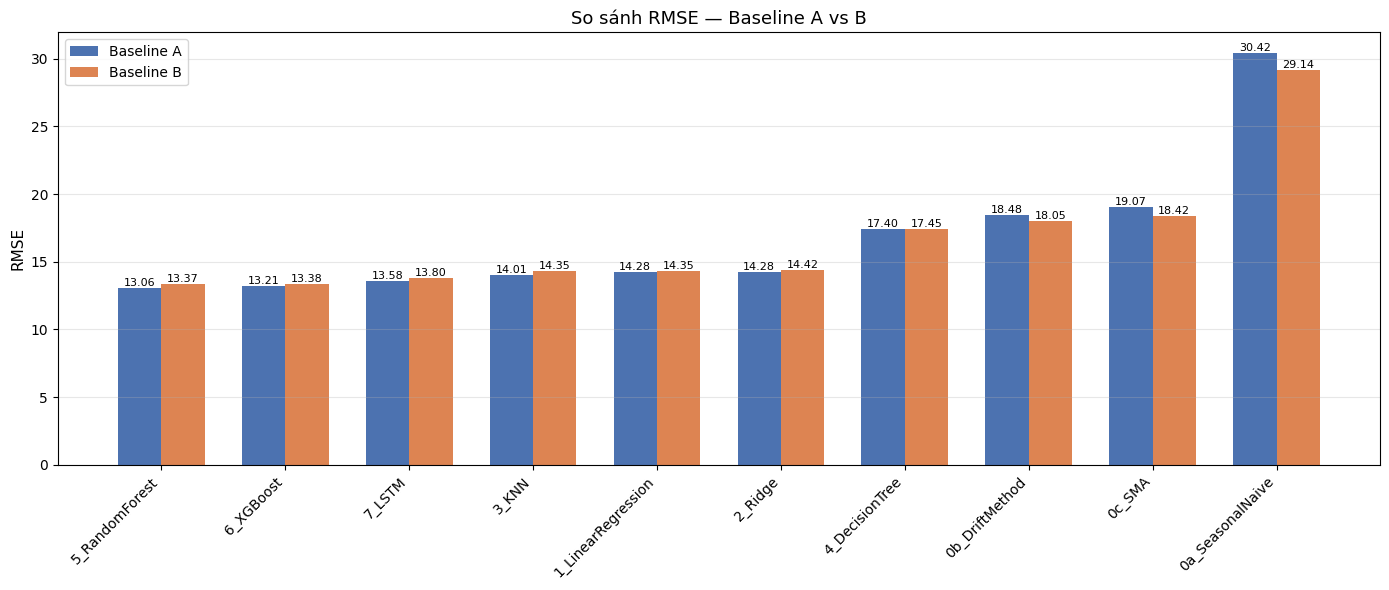

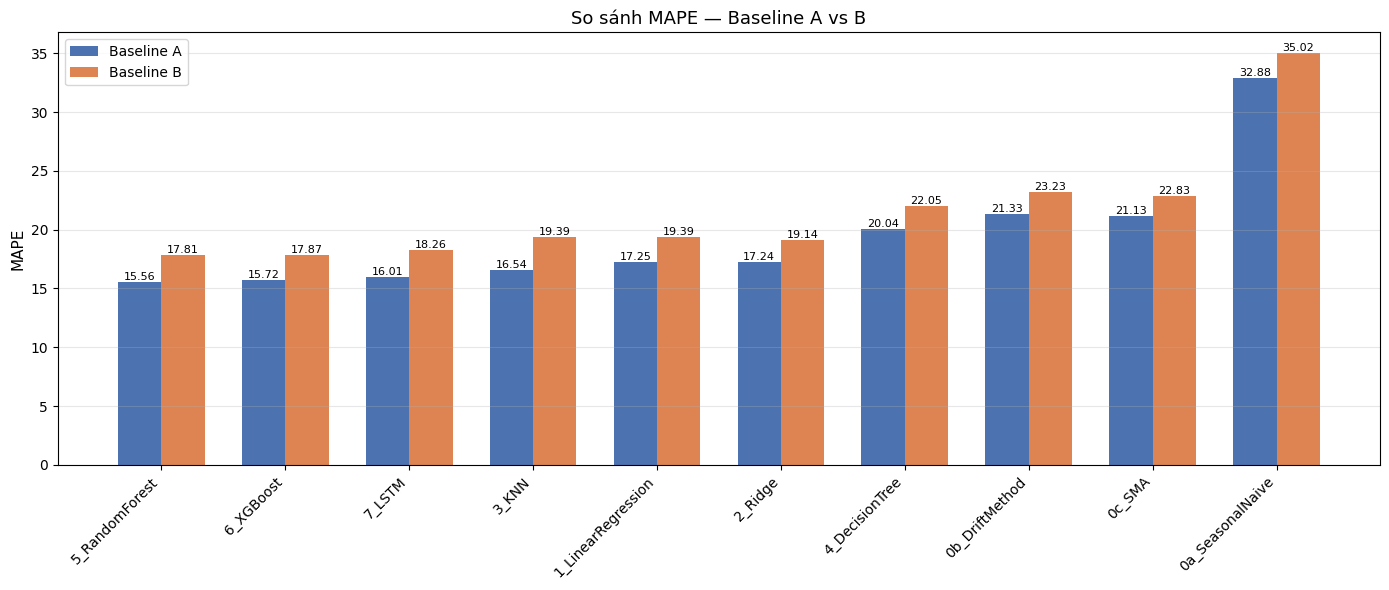

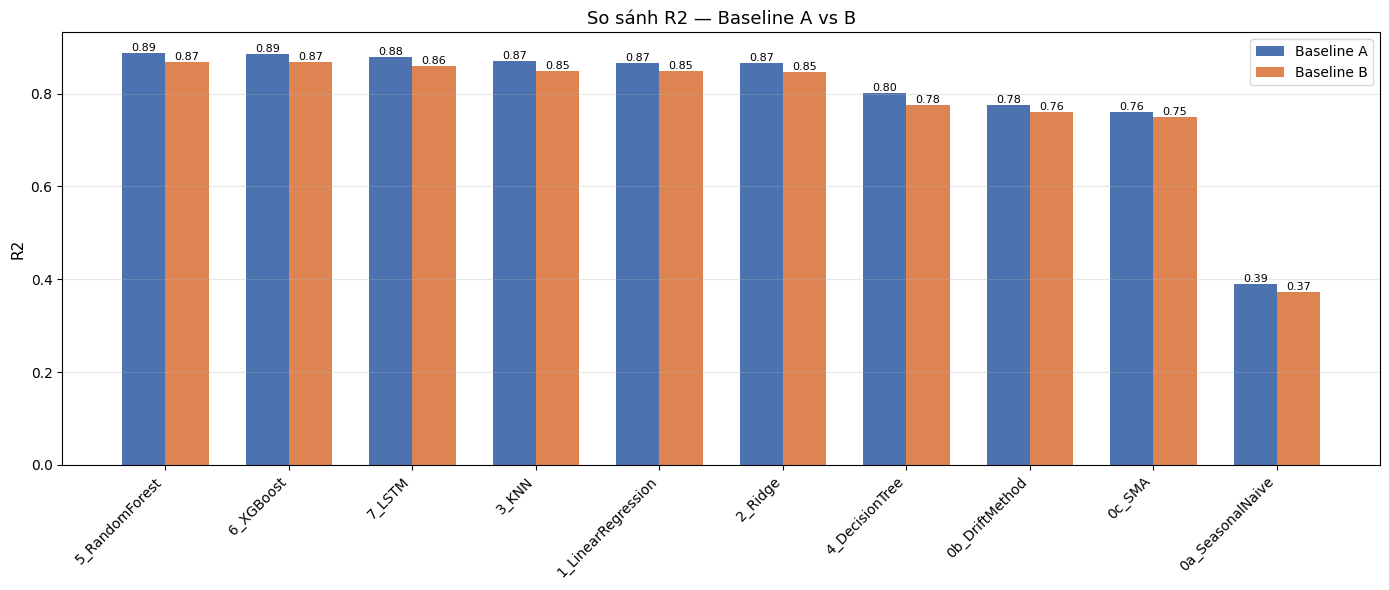

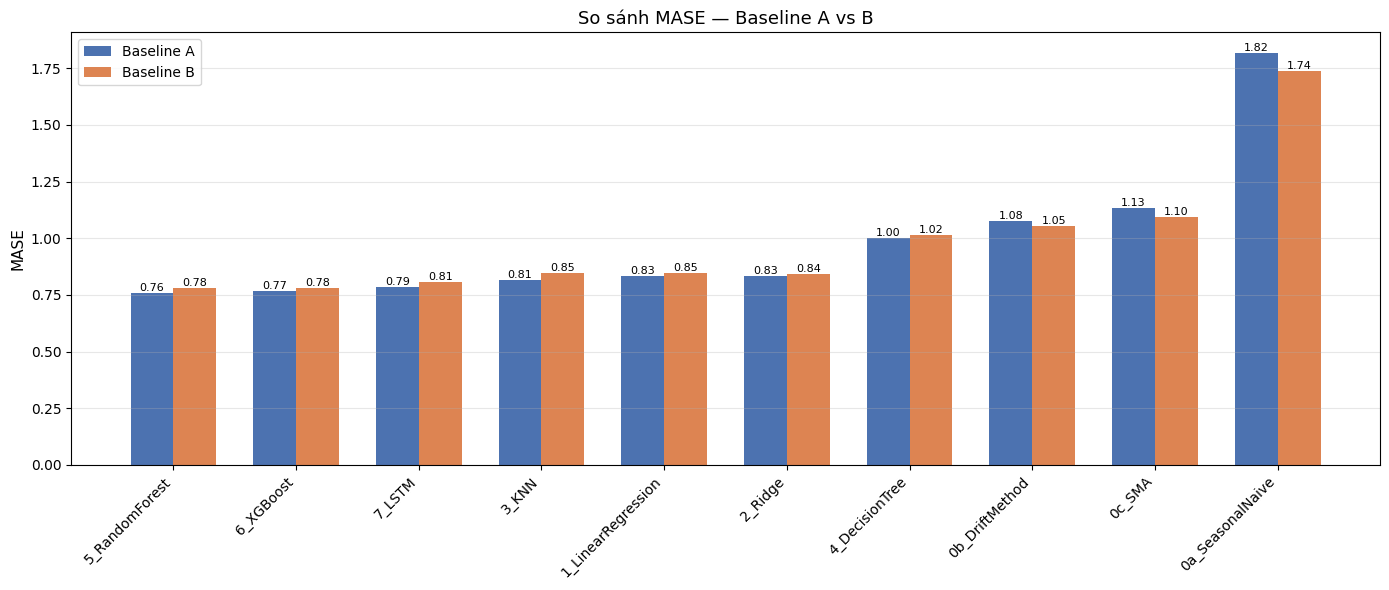

In [26]:
comparison.plot_comparison_all_metrics(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.3. Radar Chart — R²

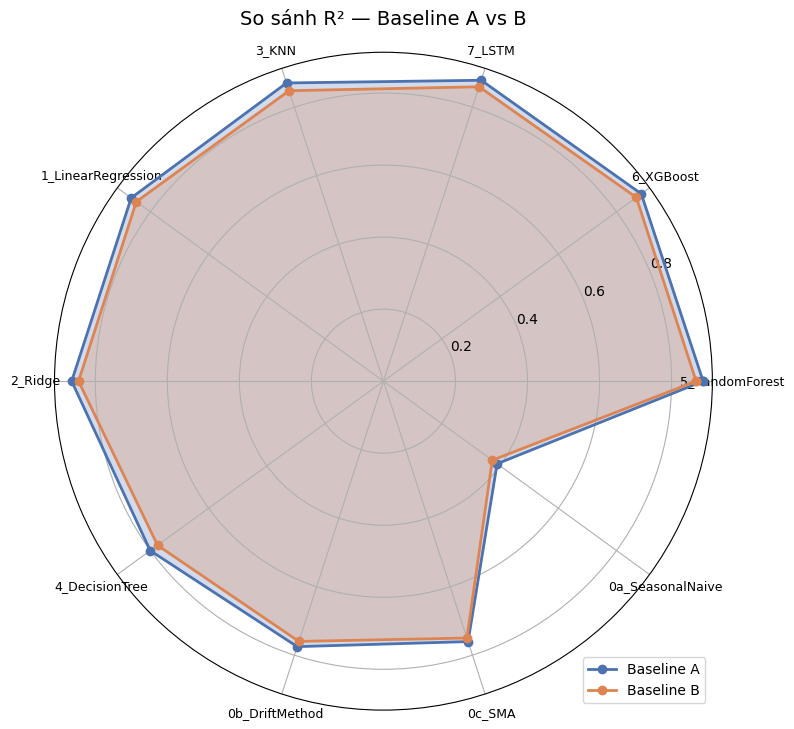

In [27]:
comparison.plot_comparison_radar(
    results_a, results_b,
    save_dir=CONFIG['images_dir']
)

### 6.4. Actual vs Predicted — Mô hình tốt nhất

🏆 Best Baseline A: 5_RandomForest
🏆 Best Baseline B: 6_XGBoost


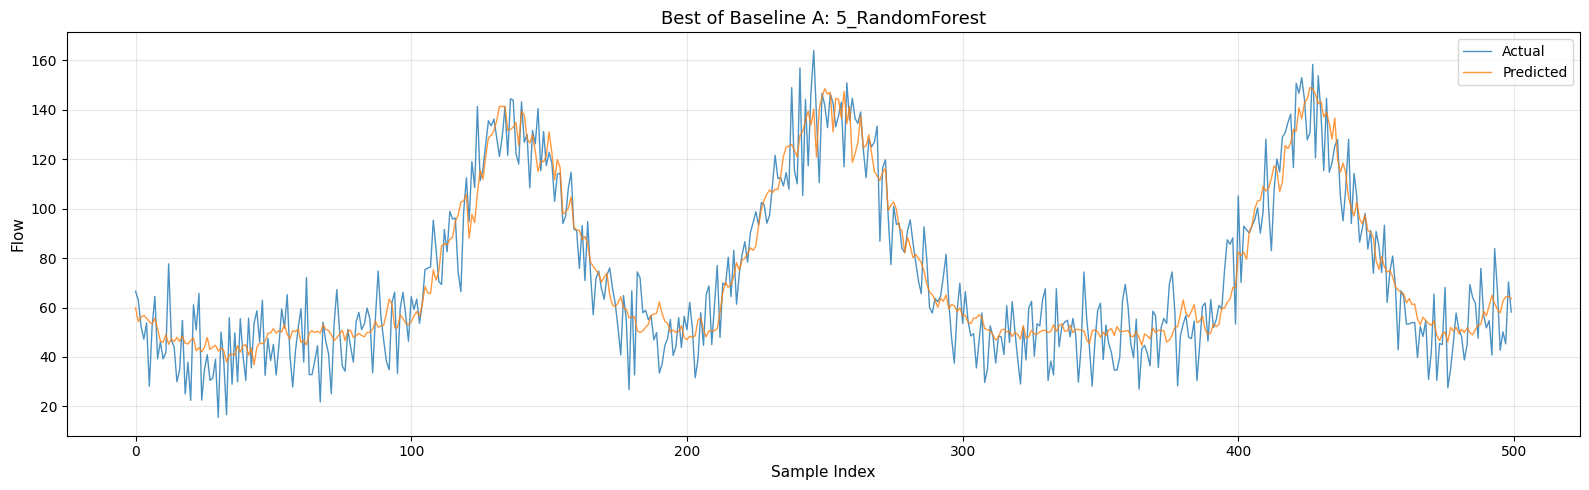

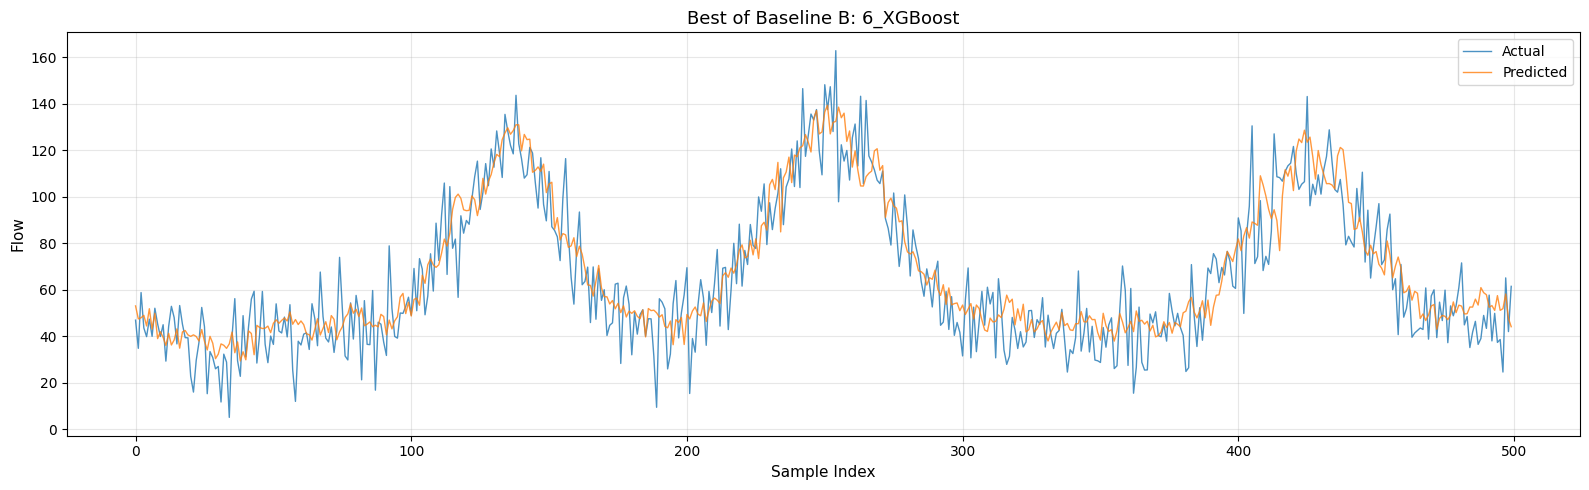

In [28]:
# Tìm mô hình tốt nhất (RMSE thấp nhất) cho mỗi baseline
best_a_name = results_a.loc[results_a['test_RMSE'].idxmin(), 'model']
best_b_name = results_b.loc[results_b['test_RMSE'].idxmin(), 'model']

print(f'🏆 Best Baseline A: {best_a_name}')
print(f'🏆 Best Baseline B: {best_b_name}')

# Vẽ Actual vs Predicted cho mô hình tốt nhất
viz.plot_actual_vs_predicted(
    y_test_a, trained_a[best_a_name]['y_pred_test'],
    title=f'Best of Baseline A: {best_a_name}',
    save_path=f"{CONFIG['images_dir']}/best_A.png"
)
viz.plot_actual_vs_predicted(
    y_test_b, trained_b[best_b_name]['y_pred_test'],
    title=f'Best of Baseline B: {best_b_name}',
    save_path=f"{CONFIG['images_dir']}/best_B.png"
)

### 6.5. Nhận xét & Kết luận

In [29]:
conclusion = comparison.generate_conclusion(results_a, results_b)

📋 NHẬN XÉT & KẾT LUẬN

🏆 Mô hình tốt nhất Baseline A: 5_RandomForest
   RMSE=13.06, MAE=10.38, R²=0.8876

🏆 Mô hình tốt nhất Baseline B: 6_XGBoost
   RMSE=13.37, MAE=10.62, R²=0.8682

📊 RMSE trung bình: A=16.78, B=16.67
   → Baseline B có kết quả dự báo tốt hơn tổng thể.

📝 So sánh chi tiết từng mô hình:
   5_RandomForest: A=13.06 vs B=13.38 → Baseline A tốt hơn (chênh 0.32)
   6_XGBoost: A=13.21 vs B=13.37 → Baseline A tốt hơn (chênh 0.15)
   7_LSTM: A=13.58 vs B=13.80 → Baseline A tốt hơn (chênh 0.22)
   3_KNN: A=14.01 vs B=14.42 → Baseline A tốt hơn (chênh 0.41)
   1_LinearRegression: A=14.28 vs B=14.35 → Baseline A tốt hơn (chênh 0.08)
   2_Ridge: A=14.28 vs B=14.35 → Baseline A tốt hơn (chênh 0.07)
   4_DecisionTree: A=17.40 vs B=17.45 → Baseline A tốt hơn (chênh 0.05)
   0b_DriftMethod: A=18.48 vs B=18.05 → Baseline B tốt hơn (chênh 0.43)
   0c_SMA: A=19.07 vs B=18.42 → Baseline B tốt hơn (chênh 0.66)
   0a_SeasonalNaive: A=30.42 vs B=29.14 → Baseline B tốt hơn (chênh 1.28)


---
## 7. Tối ưu hóa đa mục tiêu siêu tham số (Pymoo)

Sau khi so sánh 2 baseline, chọn **2 mô hình tốt nhất** (có RMSE tốt trên cả 2 baseline)
để tối ưu hóa siêu tham số bằng bài toán **đa mục tiêu**.

**3 mục tiêu (tất cả minimize):**
1. **RMSE** — Chất lượng dự báo
2. **Search time** — Thời gian huấn luyện
3. **Model complexity** — Độ phức tạp mô hình

**Thuật toán:** NSGA-II (hoặc NSGA-III nếu cần)

### 7.1. Chọn 2 mô hình tốt nhất

In [30]:
from modules import optimization as optim

# Chọn 2 mô hình có RMSE trung bình tốt nhất trên cả 2 baselines
best_model_names = optim.select_best_models(results_a, results_b, top_n=2)
print(f'\nSẽ tối ưu hóa: {best_model_names}')

🏆 Top 2 mô hình tốt nhất trên CẢ HAI baselines:
   5_RandomForest: A_RMSE=13.0622, B_RMSE=13.3811, Avg=13.2217
   6_XGBoost: A_RMSE=13.2118, B_RMSE=13.3665, Avg=13.2891

Sẽ tối ưu hóa: ['5_RandomForest', '6_XGBoost']


### 7.2. Cấu hình tối ưu hóa

In [31]:
from configs.configs import OPTIM_CONFIG
print(f'✅ OPTIM_CONFIG: {OPTIM_CONFIG}')

✅ OPTIM_CONFIG: {'pop_size': 300, 'n_gen': 100, 'algorithm': 'nsga2', 'random_state': 69}


### 7.3. Chạy tối ưu hóa — Baseline A

In [32]:
pareto_results_a = {}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'🔍 Tối ưu {model_name} trên Baseline A')
    print(f'{"="*60}')
    
    result, pareto_df, problem = optim.run_optimization(
        model_name = model_name,
        X_train = X_train_a, 
        y_train = y_train_a,
        X_valid = X_valid_a, 
        y_valid = y_valid_a,
        **OPTIM_CONFIG,
        train_subsample_ratio = 1.0,
        baseline_tag = 'A'
    )

    pareto_results_a[model_name] = {
        'result': result,
        'pareto_df': pareto_df,
        'problem': problem,
    }
        
    # Hiển thị top 10 nghiệm Pareto (sắp xếp theo RMSE)
    print(f'\n📋 Top 10 nghiệm Pareto ({model_name}):')
    display(pareto_df.head(10))


🔍 Tối ưu 5_RandomForest trên Baseline A

✅ Checkpoint cho 5_RandomForest [A] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 55155.8s
   Số nghiệm Pareto: 90
   RMSE range: [13.1261, 14.9723]
   Time range: [5.4659s, 41.1745s]

📋 Top 10 nghiệm Pareto (5_RandomForest):


,n_gen,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,train_time_s,complexity
0,64,130,12,20,1,13.1261,36.5457,1560.0
1,64,127,12,20,1,13.1265,41.1745,1524.0
2,64,126,12,20,1,13.1269,34.9464,1512.0
3,64,125,12,20,1,13.1271,35.4707,1500.0
4,64,130,11,20,1,13.1276,32.0536,1430.0
5,64,127,11,20,1,13.1279,33.0447,1397.0
6,64,126,11,20,1,13.1286,32.8369,1386.0
7,64,125,11,20,1,13.1291,37.4985,1375.0
8,64,115,12,20,1,13.1297,33.4800,1380.0
9,63,114,12,20,1,13.1301,39.4630,1368.0



🔍 Tối ưu 6_XGBoost trên Baseline A

✅ Checkpoint cho 6_XGBoost [A] đã hoàn tất 101/100 thế hệ. Không cần chạy lại.

✅ Tối ưu hóa hoàn tất trong 3427.7s
   Số nghiệm Pareto: 117
   RMSE range: [12.6890, 12.9914]
   Time range: [0.3573s, 1.2146s]

📋 Top 10 nghiệm Pareto (6_XGBoost):


,n_gen,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,RMSE,train_time_s,complexity
0,79,162,3,0.177464,0.898611,0.831690,8.883969,5.121445,12.6890,1.1140,486.0
1,98,105,3,0.181722,0.900854,0.941635,3.675371,0.725724,12.6948,1.2146,315.0
2,95,115,3,0.181468,0.900862,0.931594,3.932845,0.730305,12.6957,0.7421,345.0
3,98,112,3,0.181481,0.900862,0.927423,3.655402,0.695535,12.6959,0.9648,336.0
4,98,114,3,0.181474,0.900855,0.931283,3.559945,0.730298,12.6974,0.8059,342.0
5,84,114,3,0.181477,0.900854,0.931668,3.559945,0.730298,12.6974,0.7109,342.0
6,86,109,3,0.181729,0.900854,0.930003,3.592222,0.730298,12.6981,0.8778,327.0
7,97,110,3,0.181726,0.900853,0.920307,3.509373,0.730298,12.6981,0.7525,330.0
8,99,102,3,0.181726,0.900853,0.920307,3.509373,0.730298,12.6997,0.9828,306.0
9,97,109,3,0.181730,0.900862,0.927879,3.513249,0.725472,12.7033,0.7534,327.0


### 7.4. Chạy tối ưu hóa — Baseline B

In [33]:
pareto_results_b = {}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'🔍 Tối ưu {model_name} trên Baseline B')
    print(f'{"="*60}')
    
    result, pareto_df, problem = optim.run_optimization(
        model_name = model_name,
        X_train = X_train_b, 
        y_train = y_train_b,
        X_valid = X_valid_b, 
        y_valid = y_valid_b,
        **OPTIM_CONFIG,
        train_subsample_ratio = 1.0,
        baseline_tag = 'B'
    )
    pareto_results_b[model_name] = {
        'result': result,
        'pareto_df': pareto_df,
        'problem': problem,
    }
    
    print(f'\n📋 Top 10 nghiệm Pareto ({model_name}):')
    display(pareto_df.head(10))


🔍 Tối ưu 5_RandomForest trên Baseline B

🔄 RESUME 5_RandomForest [B] từ checkpoint: 86/100 thế hệ đã xong.

🔍 TỐI ƯU HÓA 5_RandomForest [B]
   Thuật toán: NSGA2
   Quần thể: 300 | Thế hệ: 100 (resume 86→100)
   Biến quyết định: 4
   Mục tiêu: RMSE ↓, Train time ↓, Complexity ↓
   Subsample ratio: 100% (16892/16892 mẫu)
   Song song: 15 jobs
   Checkpoint: pymooCheckpoint\optim_checkpoint_B_5_RandomForest.pkl (mỗi 1 gen)


h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

    86 |    27000 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 86/100 (744861s tổng)


h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


    87 |    27300 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 87/100 (746361s tổng)
    88 |    27600 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 88/100 (747612s tổng)
    89 |    27900 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 89/100 (748606s tổng)
    90 |    28200 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 90/100 (749592s tổng)
    91 |    28500 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 91/100 (750605s tổng)
    92 |    28800 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 92/100 (751574s tổng)
    93 |    29100 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 93/100 (752512s tổng)
    94 |    29400 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 94/100 (753476s tổng)
    95 |    29700 |     89 |  0.0001331588 |             f
   💾 Checkpoint saved: gen 95/100 (754470s tổng)
    96 |    30000 |     89 |

,n_gen,n_estimators,max_depth,min_samples_split,min_samples_leaf,RMSE,train_time_s,complexity
0,84,143,10,18,5,13.0421,35.4952,1430.0
1,84,142,10,18,5,13.0431,35.9722,1420.0
2,85,141,10,18,5,13.0431,37.8232,1410.0
3,85,140,10,18,5,13.0436,39.4803,1400.0
4,85,139,10,18,5,13.0451,37.7560,1390.0
5,83,141,10,19,5,13.0452,36.9985,1410.0
6,85,138,10,18,5,13.0464,43.8549,1380.0
7,85,138,10,17,5,13.0466,35.2163,1380.0
8,85,134,10,18,5,13.0471,34.5773,1340.0
9,85,101,10,18,5,13.0476,32.8512,1010.0



🔍 Tối ưu 6_XGBoost trên Baseline B

🔍 TỐI ƯU HÓA 6_XGBoost [B]
   Thuật toán: NSGA2
   Quần thể: 300 | Thế hệ: 100 (từ đầu)
   Biến quyết định: 7
   Mục tiêu: RMSE ↓, Train time ↓, Complexity ↓
   Subsample ratio: 100% (16892/16892 mẫu)
   Song song: 15 jobs
   Checkpoint: pymooCheckpoint\optim_checkpoint_B_6_XGBoost.pkl (mỗi 1 gen)
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      300 |      7 |             - |             -
   💾 Checkpoint saved: gen 1/100 (635s tổng)
     2 |      600 |     12 |  0.0583714026 |         ideal
   💾 Checkpoint saved: gen 2/100 (1058s tổng)
     3 |      900 |     18 |  0.0858171424 |         ideal
   💾 Checkpoint saved: gen 3/100 (1151s tổng)
     4 |     1200 |     25 |  0.1184151794 |         ideal
   💾 Checkpoint saved: gen 4/100 (1192s tổng)
     5 |     1500 |     34 |  0.1712962963 |         nadir
   💾 Checkpoint saved: gen 5/100 (1227s tổng)
     6 |     1800 |     36 |  0.0370732761 |         ideal
   💾 Checkpoint saved:

,n_gen,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,RMSE,train_time_s,complexity
0,78,159,3,0.188498,0.961760,0.643028,9.645168,7.228804,12.5490,1.4592,477.0
1,76,159,3,0.188495,0.961760,0.640415,9.654124,7.223636,12.5490,1.3988,477.0
2,90,159,3,0.188496,0.961762,0.640494,9.638108,7.228496,12.5490,1.5864,477.0
3,95,159,3,0.188549,0.961760,0.645119,9.645168,7.228804,12.5491,1.0589,477.0
4,86,159,3,0.188547,0.961759,0.645248,9.651582,7.230004,12.5491,1.2919,477.0
5,92,134,3,0.184822,0.964382,0.635583,9.487574,6.008389,12.5503,1.4856,402.0
6,96,134,3,0.184822,0.964382,0.635583,9.755400,6.008389,12.5503,1.5375,402.0
7,67,157,3,0.188553,0.961759,0.646128,9.655111,7.228504,12.5513,1.0692,471.0
8,93,156,3,0.188531,0.961760,0.659434,9.655111,7.228504,12.5517,1.2433,468.0
9,54,151,3,0.188549,0.961760,0.646069,9.655111,7.228504,12.5542,0.9895,453.0


### 7.5. Trực quan hóa Pareto Front


--- Pareto Front: 5_RandomForest ---

📊 Baseline A:


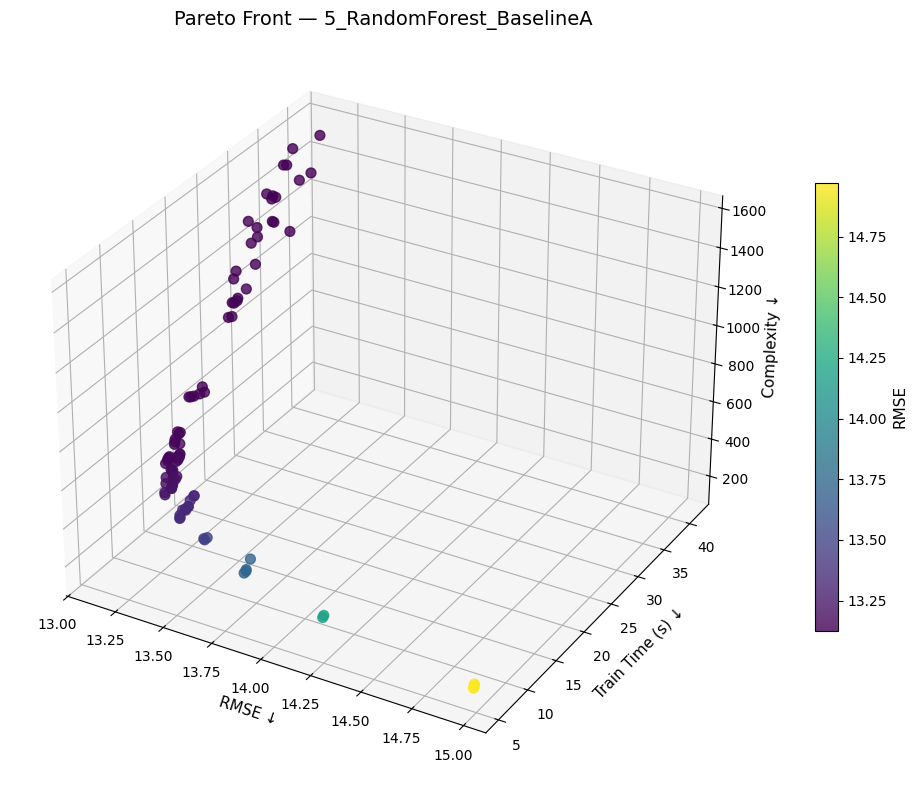

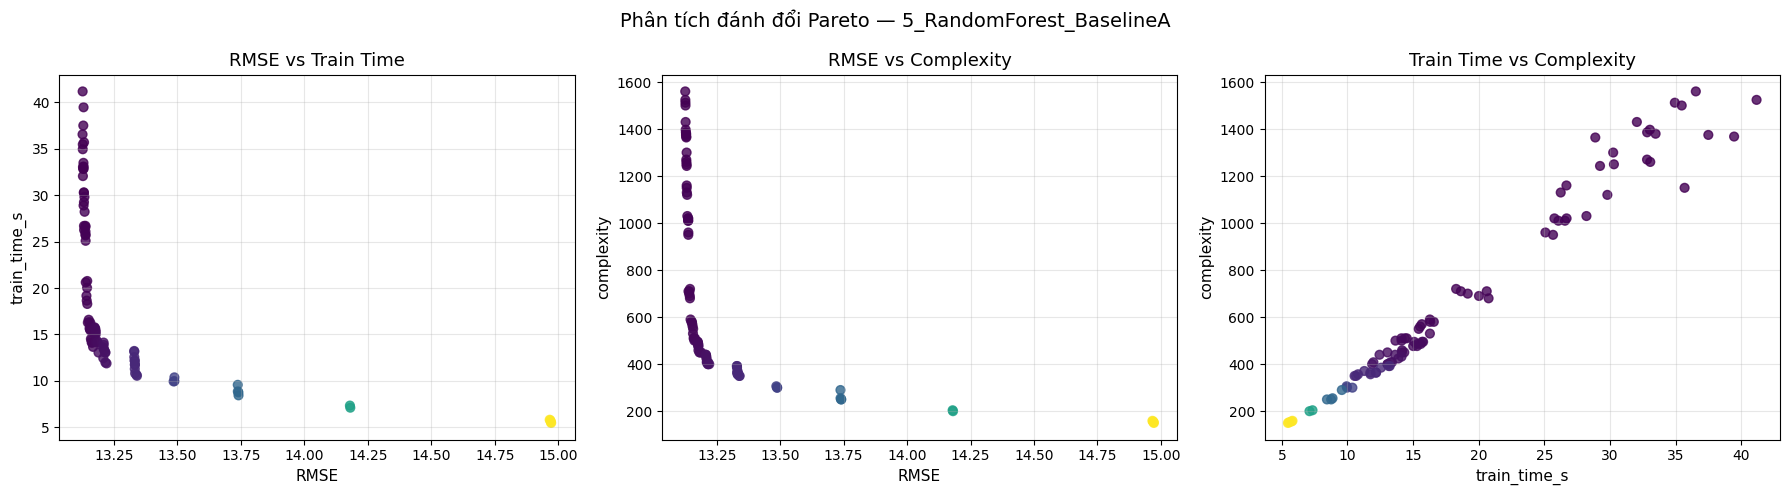


📊 Baseline B:


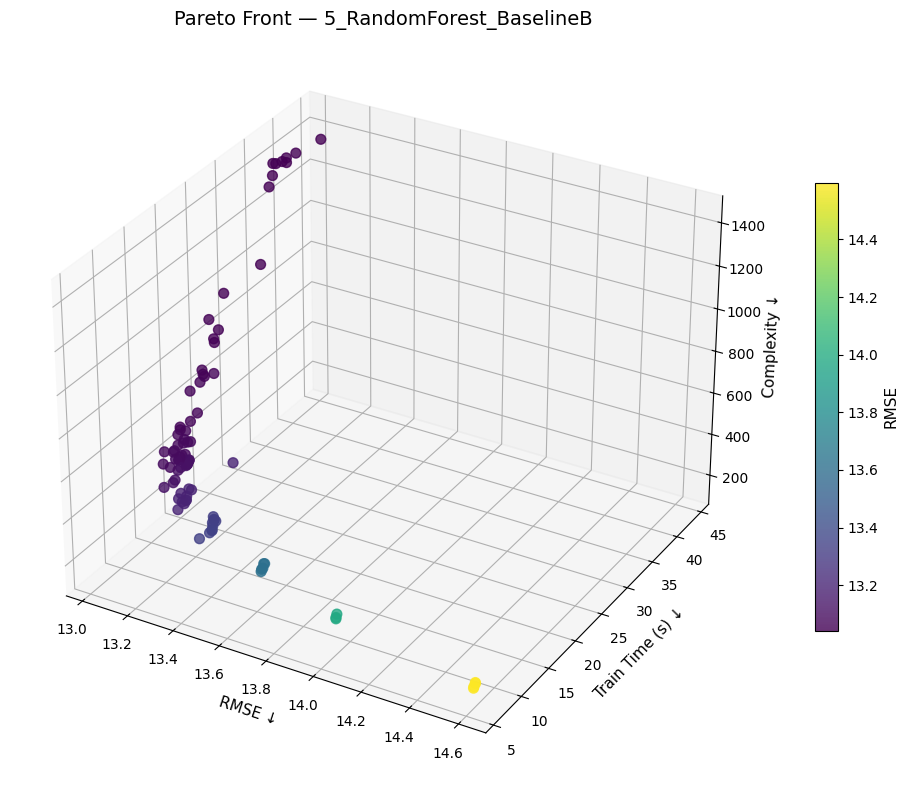

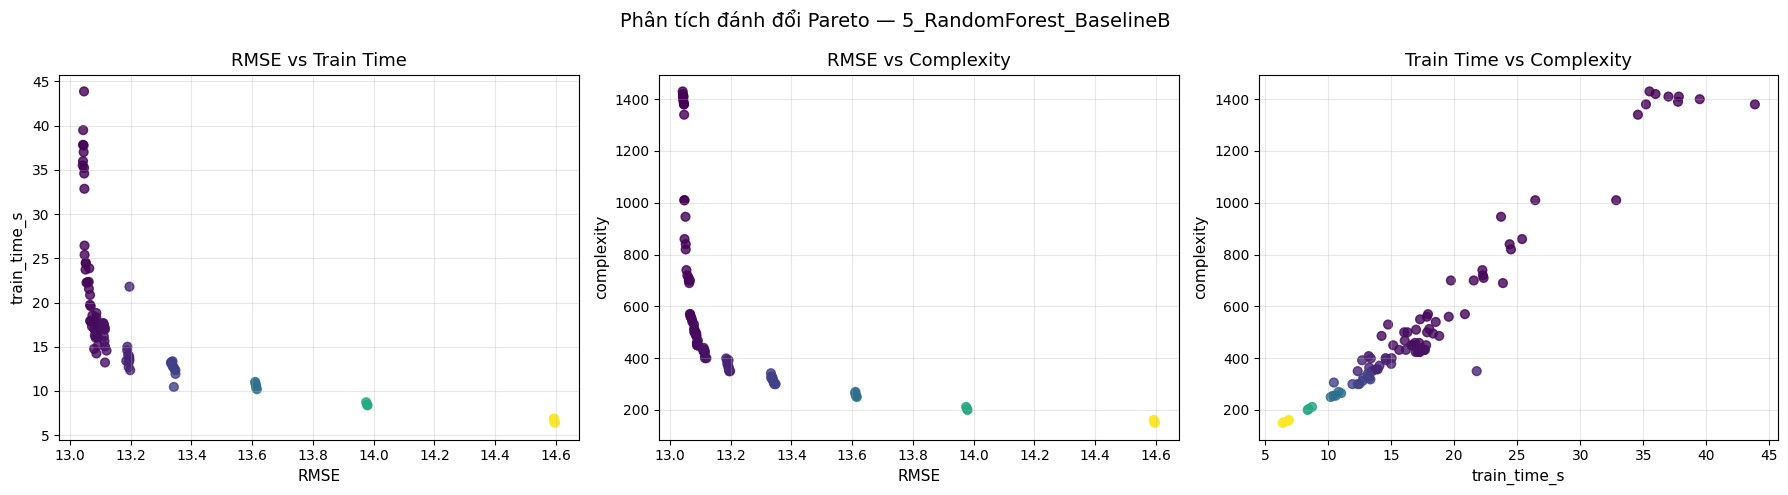


--- Pareto Front: 6_XGBoost ---

📊 Baseline A:


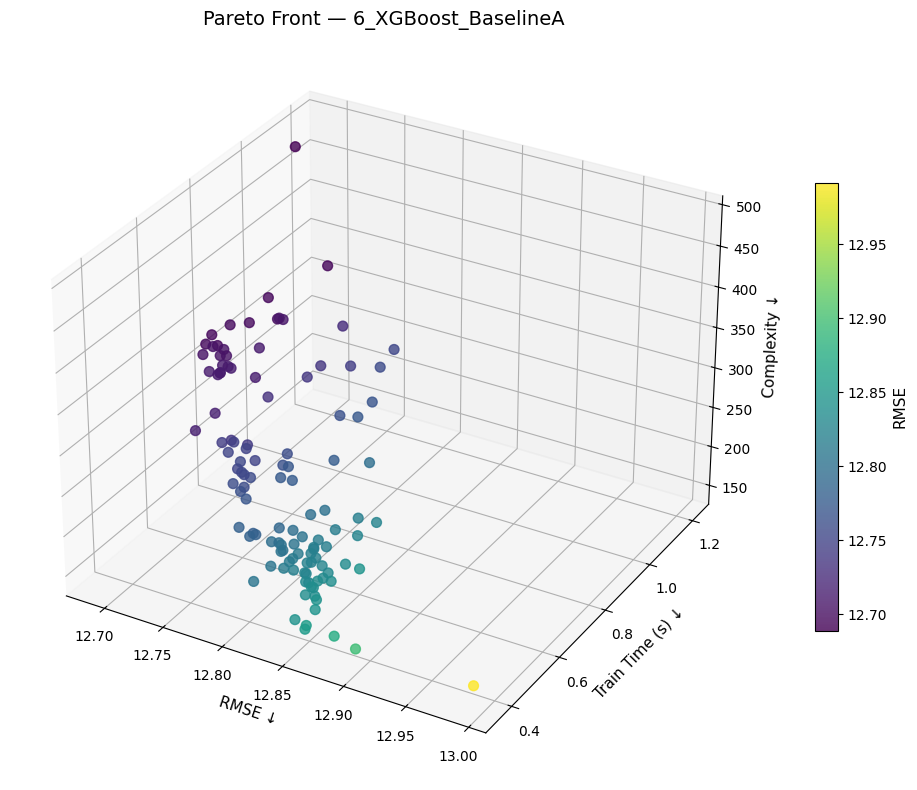

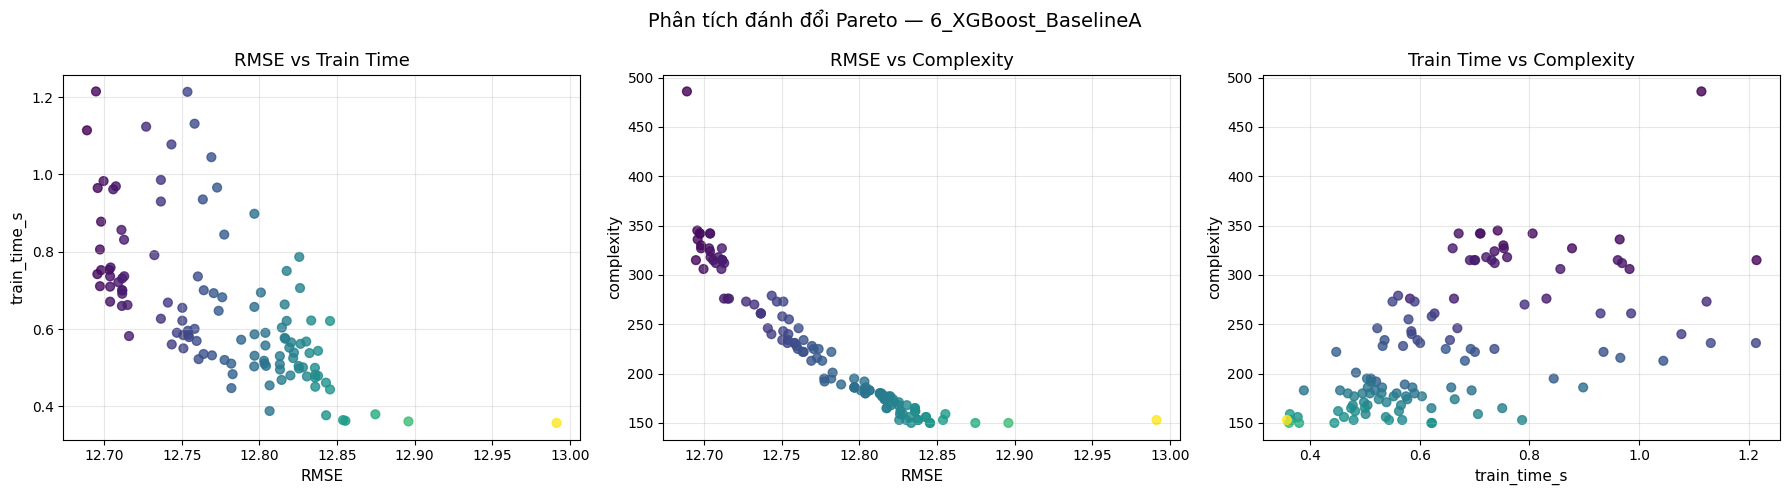


📊 Baseline B:


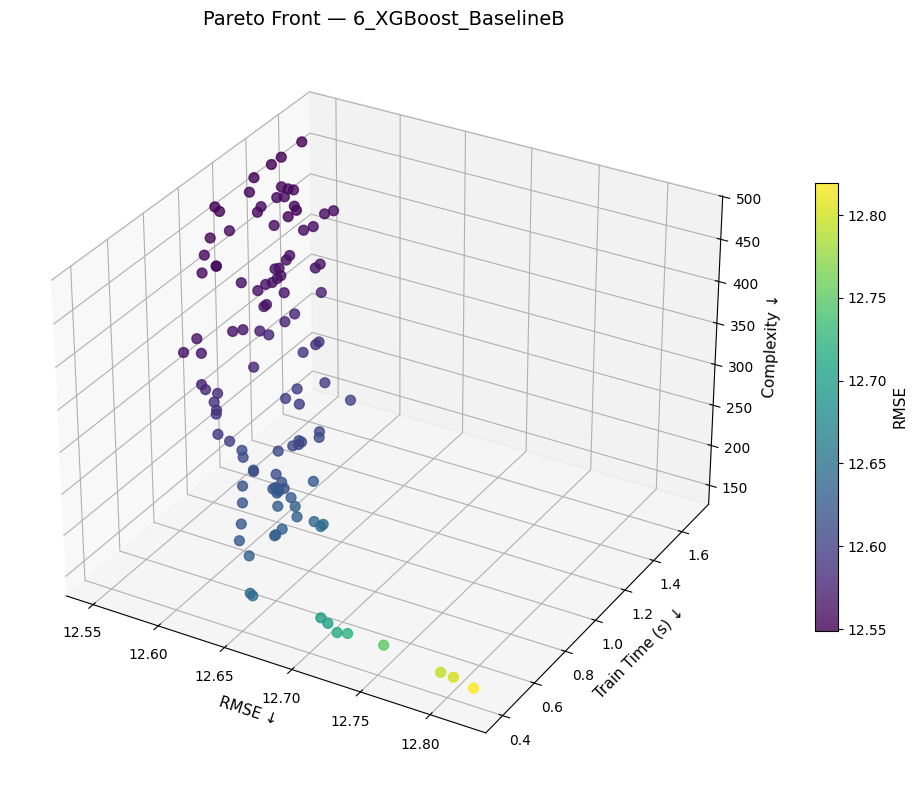

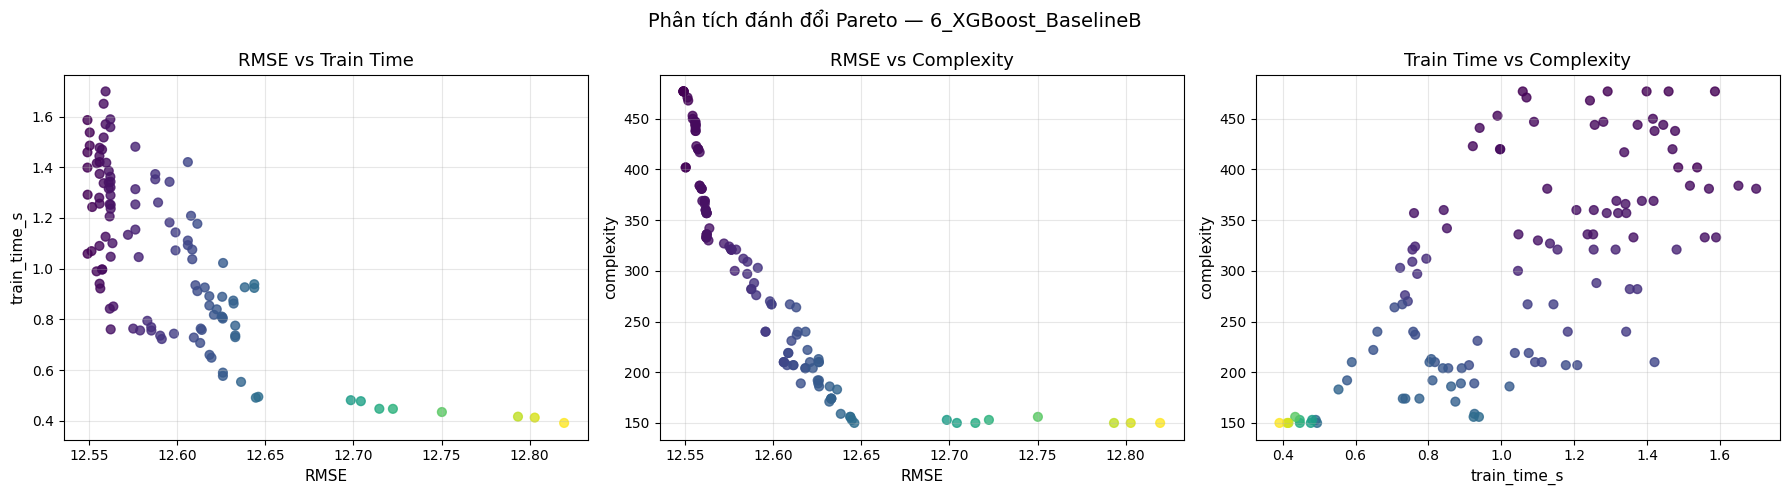

In [34]:
for model_name in best_model_names:
    print(f'\n--- Pareto Front: {model_name} ---')
    
    # Baseline A
    print('\n📊 Baseline A:')
    pareto_a = pareto_results_a[model_name]['pareto_df']
    optim.plot_pareto_front_3d(pareto_a, f'{model_name}_BaselineA',
                               save_dir=CONFIG['images_dir'])
    optim.plot_pareto_2d_pairs(pareto_a, f'{model_name}_BaselineA',
                               save_dir=CONFIG['images_dir'])
    
    # Baseline B
    print('\n📊 Baseline B:')
    pareto_b = pareto_results_b[model_name]['pareto_df']
    optim.plot_pareto_front_3d(pareto_b, f'{model_name}_BaselineB',
                               save_dir=CONFIG['images_dir'])
    optim.plot_pareto_2d_pairs(pareto_b, f'{model_name}_BaselineB',
                               save_dir=CONFIG['images_dir'])

### 7.6. Phân tích đánh đổi (Trade-off Analysis)

In [35]:
optimized_solutions = {'Baseline_A': {}, 'Baseline_B': {}}
optimized_params = {'Baseline_A': {}, 'Baseline_B': {}}

for model_name in best_model_names:
    print(f'\n{"="*60}')
    print(f'📊 PHÂN TÍCH ĐÁNH ĐỔI — {model_name}')

    print('\n--- Baseline A ---')
    pareto_a = pareto_results_a[model_name]['pareto_df']
    conclusion_a, best_a = optim.analyze_tradeoffs(pareto_a, f'{model_name} (Baseline A)')
    optimized_solutions['Baseline_A'][model_name] = best_a
    optimized_params['Baseline_A'][model_name] = stability.params_from_solution(model_name, best_a)

    print('\n--- Baseline B ---')
    pareto_b = pareto_results_b[model_name]['pareto_df']
    conclusion_b, best_b = optim.analyze_tradeoffs(pareto_b, f'{model_name} (Baseline B)')
    optimized_solutions['Baseline_B'][model_name] = best_b
    optimized_params['Baseline_B'][model_name] = stability.params_from_solution(model_name, best_b)

    print(f'\n🎯 Nghiệm cân bằng được đề xuất:')
    print(f'   Baseline A params: {optimized_params["Baseline_A"][model_name]}')
    print(f'   Baseline B params: {optimized_params["Baseline_B"][model_name]}')



📊 PHÂN TÍCH ĐÁNH ĐỔI — 5_RandomForest

--- Baseline A ---

📊 PHÂN TÍCH ĐÁNH ĐỔI — 5_RandomForest (Baseline A)
   Số nghiệm Pareto: 90

🎯 Nghiệm tốt nhất theo RMSE:
   RMSE=13.1261, Time=36.546s, Complexity=1560, n_gen=64
   Params: {n_estimators=130, max_depth=12, min_samples_split=20, min_samples_leaf=1}

⚡ Nghiệm nhanh nhất:
   RMSE=14.9723, Time=5.466s, Complexity=150, n_gen=63
   Params: {n_estimators=50, max_depth=3, min_samples_split=16, min_samples_leaf=7}

🧩 Nghiệm đơn giản nhất:
   RMSE=14.9723, Time=5.466s, Complexity=150, n_gen=63
   Params: {n_estimators=50, max_depth=3, min_samples_split=16, min_samples_leaf=7}

📈 Phạm vi đánh đổi:
   RMSE: 13.1261 → 14.9723 (range=1.8462)
   Time: 5.466s → 41.175s (range=35.709s)
   Complexity: 150 → 1560 (range=1410)

💡 Insight đánh đổi:
   Giảm 1 đơn vị RMSE cần ~19.3s thêm thời gian huấn luyện.

🔑 Nghiệm cân bằng (compromise solution):
   RMSE=13.3405, Time=10.545s, Complexity=350, n_gen=64
   Params: {n_estimators=50, max_depth=7, mi

---
## 8. Chứng minh độ ổn định bằng mô phỏng Monte Carlo

Sau khi Pymoo chọn nghiệm cân bằng cho từng mô hình, chạy Monte Carlo cho **4 trường hợp tối ưu**: 2 mô hình tốt nhất × 2 baseline. Vì đây là bài toán chuỗi thời gian, split train/valid/test phải giữ cố định theo thời gian; Monte Carlo chỉ thay đổi `random_state` của thuật toán để đo độ nhạy do tính ngẫu nhiên khi huấn luyện.


### 8.1. Cấu hình Monte Carlo


In [36]:
from configs.configs import STABILITY_CONFIG

mc_runs = STABILITY_CONFIG['monte_carlo_runs']
mc_seed_start = STABILITY_CONFIG['monte_carlo_seed_start']
mc_seeds = list(range(mc_seed_start, mc_seed_start + mc_runs))

print(f'✅ STABILITY_CONFIG: {STABILITY_CONFIG}')
print(f'Monte Carlo seeds: {mc_seeds[0]} → {mc_seeds[-1]} ({len(mc_seeds)} runs)')


✅ STABILITY_CONFIG: {'monte_carlo_runs': 100, 'monte_carlo_seed_start': 1000, 'sliding_train_ratio': 0.6, 'sliding_test_ratio': 0.1, 'sliding_step_ratio': 0.05, 'sliding_n_folds': 5, 'sliding_random_state': 69, 'stable_cv_threshold': 10.0}
Monte Carlo seeds: 1000 → 1099 (100 runs)


### 8.2. Chạy Monte Carlo cho 4 mô hình tối ưu


In [37]:
monte_carlo_inputs = {
    'Baseline_A': {
        'X_train': X_train_a,
        'y_train': y_train_a,
        'X_valid': X_valid_a,
        'y_valid': y_valid_a,
        'X_test': X_test_a,
        'y_test': y_test_a,
    },
    'Baseline_B': {
        'X_train': X_train_b,
        'y_train': y_train_b,
        'X_valid': X_valid_b,
        'y_valid': y_valid_b,
        'X_test': X_test_b,
        'y_test': y_test_b,
    },
}

mc_result_parts = []

for baseline_name, data in monte_carlo_inputs.items():
    for model_name in best_model_names:
        params = optimized_params[baseline_name][model_name]
        mc_df = stability.run_monte_carlo(
            model_name=model_name,
            params=params,
            X_train=data['X_train'],
            y_train=data['y_train'],
            X_valid=data['X_valid'],
            y_valid=data['y_valid'],
            X_test=data['X_test'],
            y_test=data['y_test'],
            baseline_name=baseline_name,
            seeds=mc_seeds,
        )
        mc_result_parts.append(mc_df)

monte_carlo_results = pd.concat(mc_result_parts, ignore_index=True)
monte_carlo_results



🎲 MONTE CARLO — Baseline_A — 5_RandomForest
   Runs: 100 | Split thời gian: giữ nguyên | Chỉ đổi random_state
   Run 01/100 | seed=1000 | RMSE=13.1574 | MAE=10.4523
   Run 02/100 | seed=1001 | RMSE=13.1509 | MAE=10.4460
   Run 03/100 | seed=1002 | RMSE=13.1468 | MAE=10.4417
   Run 04/100 | seed=1003 | RMSE=13.1793 | MAE=10.4718
   Run 05/100 | seed=1004 | RMSE=13.1786 | MAE=10.4595
   Run 06/100 | seed=1005 | RMSE=13.1579 | MAE=10.4492
   Run 07/100 | seed=1006 | RMSE=13.2055 | MAE=10.4785
   Run 08/100 | seed=1007 | RMSE=13.1826 | MAE=10.4713
   Run 09/100 | seed=1008 | RMSE=13.1749 | MAE=10.4529
   Run 10/100 | seed=1009 | RMSE=13.1694 | MAE=10.4652
   Run 11/100 | seed=1010 | RMSE=13.1937 | MAE=10.4810
   Run 12/100 | seed=1011 | RMSE=13.1735 | MAE=10.4635
   Run 13/100 | seed=1012 | RMSE=13.1854 | MAE=10.4721
   Run 14/100 | seed=1013 | RMSE=13.1796 | MAE=10.4719
   Run 15/100 | seed=1014 | RMSE=13.2012 | MAE=10.4802
   Run 16/100 | seed=1015 | RMSE=13.1537 | MAE=10.4431
   Run 17

,baseline,model,run,random_state,train_time_s,MAE,RMSE,MAPE,R2,MASE
0,Baseline_A,5_RandomForest,1,1000,1.7637,10.4523,13.1574,15.6525,0.8859,0.7645
1,Baseline_A,5_RandomForest,2,1001,2.2972,10.4460,13.1509,15.6179,0.8861,0.7640
2,Baseline_A,5_RandomForest,3,1002,2.2648,10.4417,13.1468,15.6382,0.8861,0.7637
3,Baseline_A,5_RandomForest,4,1003,2.7652,10.4718,13.1793,15.6694,0.8856,0.7659
4,Baseline_A,5_RandomForest,5,1004,2.2517,10.4595,13.1786,15.6741,0.8856,0.7650
...,...,...,...,...,...,...,...,...,...,...
395,Baseline_B,6_XGBoost,96,1095,0.1737,10.4146,13.1438,17.5425,0.8726,0.7687
396,Baseline_B,6_XGBoost,97,1096,0.1760,10.4398,13.1405,17.5707,0.8726,0.7705
397,Baseline_B,6_XGBoost,98,1097,0.1630,10.4554,13.1779,17.5768,0.8719,0.7717
398,Baseline_B,6_XGBoost,99,1098,0.1717,10.4304,13.1199,17.5578,0.8730,0.7698


### 8.3. Trực quan hóa kết quả Monte Carlo


,baseline,model,n_runs,RMSE_mean,RMSE_std,RMSE_min,RMSE_max,RMSE_ci95_low,RMSE_ci95_high,RMSE_cv_%
0,Baseline_A,6_XGBoost,100,12.9443,0.0319,12.8696,13.0203,12.9380,12.9505,0.2464
1,Baseline_B,6_XGBoost,100,13.1694,0.0289,13.1014,13.2419,13.1638,13.1751,0.2196
2,Baseline_A,5_RandomForest,100,13.1696,0.0148,13.1368,13.2055,13.1667,13.1725,0.1121
3,Baseline_B,5_RandomForest,100,13.3803,0.0145,13.3479,13.4111,13.3775,13.3832,0.1084


h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\modules\stability.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='case', y=metric, ax=ax, palette='Set2')
h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
h:\_School_Stuff\Hoc_HocMay_DoAn-t2\DoAn_MachineLearning_UTT\.venv\Lib\site-packages\seaborn\categorical.py:

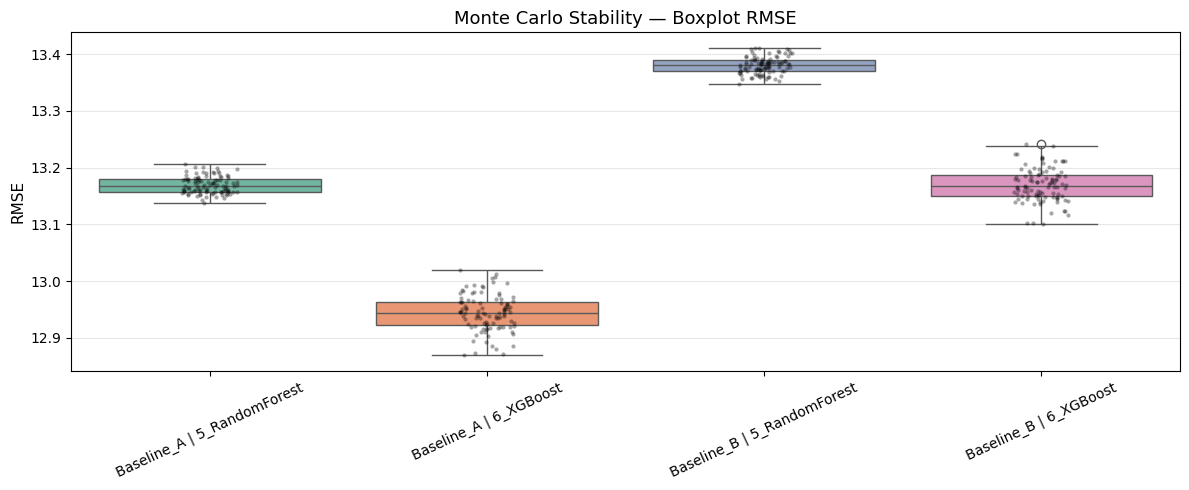

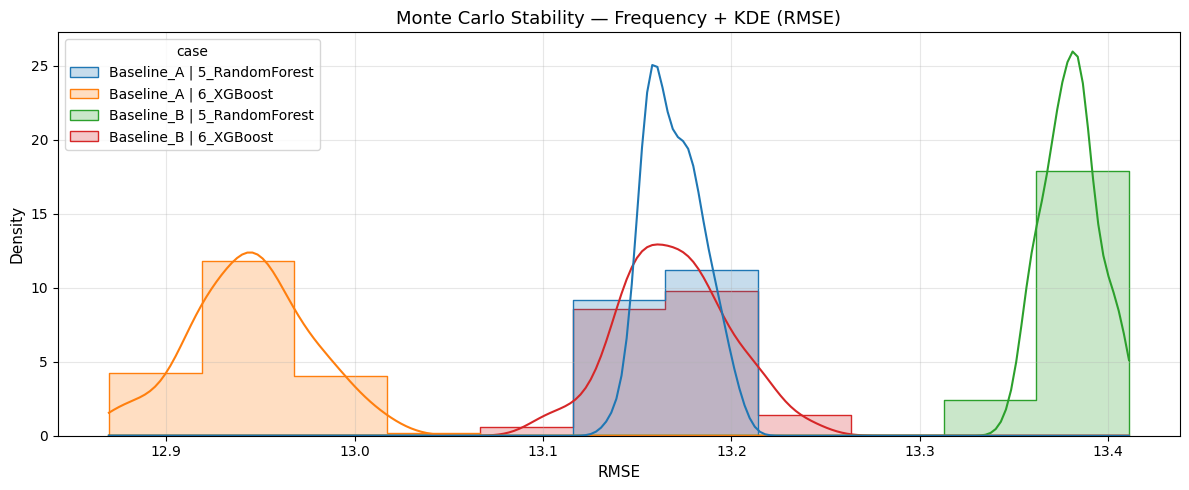

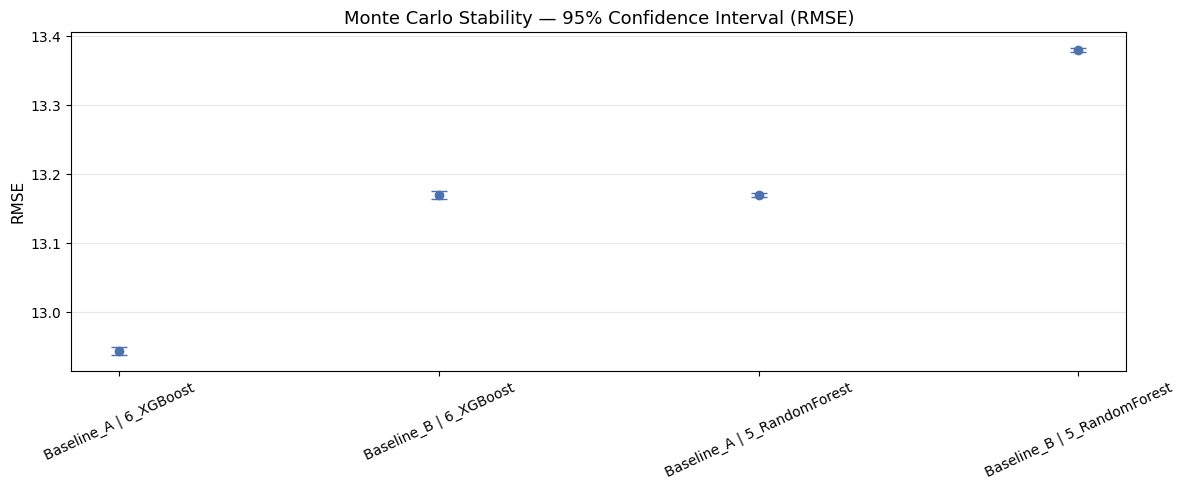

In [38]:
mc_summary = stability.summarize_monte_carlo(monte_carlo_results, metric='RMSE')
display(mc_summary)

stability.plot_monte_carlo_boxplot(
    monte_carlo_results,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_boxplot.png",
)
stability.plot_monte_carlo_kde(
    monte_carlo_results,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_kde.png",
)
stability.plot_monte_carlo_ci(
    mc_summary,
    metric='RMSE',
    save_path=f"{CONFIG['images_dir']}/monte_carlo_rmse_ci95.png",
)


---
## 9. Chứng minh độ ổn định của bộ dữ liệu bằng kỹ thuật trượt thời gian

Dùng 5 cửa sổ trượt theo đúng hướng dẫn: train 60%, test 10%, bước trượt 5%. Ở mỗi fold, tập train luôn nằm trước tập test theo thời gian, không có trộn ngẫu nhiên. Nếu RMSE trên các fold dao động nhỏ, bộ dữ liệu không có biến động bất thường lớn giữa các giai đoạn thời gian.


### 9.1. Chạy 5 cửa sổ trượt thời gian


In [39]:
sliding_inputs = {
    'Baseline_A': df_baseline_a,
    'Baseline_B': df_baseline_b,
}

sliding_result_parts = []

for baseline_name, baseline_df in sliding_inputs.items():
    for model_name in best_model_names:
        params = optimized_params[baseline_name][model_name]
        fold_df = stability.run_time_sliding_validation(
            df=baseline_df,
            feature_cols=FEATURE_COLS,
            target_col=TARGET_COL,
            model_name=model_name,
            params=params,
            baseline_name=baseline_name,
            random_state=STABILITY_CONFIG['sliding_random_state'],
            train_ratio=STABILITY_CONFIG['sliding_train_ratio'],
            test_ratio=STABILITY_CONFIG['sliding_test_ratio'],
            step_ratio=STABILITY_CONFIG['sliding_step_ratio'],
            n_folds=STABILITY_CONFIG['sliding_n_folds'],
        )
        sliding_result_parts.append(fold_df)

time_sliding_results = pd.concat(sliding_result_parts, ignore_index=True)
time_sliding_results



🪟 TIME SLIDING — Baseline_A — 5_RandomForest
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.3612
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.6224
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.4880
   Fold 4 | Train 15-75% | Test 75-85% | RMSE=13.1456
   Fold 5 | Train 20-80% | Test 80-90% | RMSE=13.1116

🪟 TIME SLIDING — Baseline_A — 6_XGBoost
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.1103
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.2981
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.1735
   Fold 4 | Train 15-75% | Test 75-85% | RMSE=12.6087
   Fold 5 | Train 20-80% | Test 80-90% | RMSE=12.6146

🪟 TIME SLIDING — Baseline_B — 5_RandomForest
   Train 60% | Test 10% | Step 5% | Folds 5
   Fold 1 | Train 0-60% | Test 60-70% | RMSE=13.1516
   Fold 2 | Train 5-65% | Test 65-75% | RMSE=13.0860
   Fold 3 | Train 10-70% | Test 70-80% | RMSE=13.3553
   Fold 4 | Train 15-75% | Test 75-85% 

,baseline,model,fold,train_pct,test_pct,n_train,n_test,train_time_s,MAE,RMSE,MAPE,R2,MASE
0,Baseline_A,5_RandomForest,1,0-60%,60-70%,14480,2412,1.3150,10.5867,13.3612,15.0452,0.8846,0.7758
1,Baseline_A,5_RandomForest,2,5-65%,65-75%,14476,2416,1.5909,10.8936,13.6224,15.4787,0.8874,0.7939
2,Baseline_A,5_RandomForest,3,10-70%,70-80%,14480,2412,1.5421,10.7957,13.4880,17.9379,0.8753,0.7852
3,Baseline_A,5_RandomForest,4,15-75%,75-85%,14480,2412,1.6421,10.4681,13.1456,20.3418,0.8380,0.7616
4,Baseline_A,5_RandomForest,5,20-80%,80-90%,14476,2416,1.6479,10.4180,13.1116,18.4015,0.8699,0.7587
5,Baseline_A,6_XGBoost,1,0-60%,60-70%,14480,2412,0.1495,10.4184,13.1103,14.8207,0.8888,0.7634
6,Baseline_A,6_XGBoost,2,5-65%,65-75%,14476,2416,0.1340,10.7117,13.2981,15.2030,0.8927,0.7807
7,Baseline_A,6_XGBoost,3,10-70%,70-80%,14480,2412,0.1460,10.5539,13.1735,17.4337,0.8810,0.7676
8,Baseline_A,6_XGBoost,4,15-75%,75-85%,14480,2412,0.1295,9.9851,12.6087,19.2774,0.8509,0.7265
9,Baseline_A,6_XGBoost,5,20-80%,80-90%,14476,2416,0.1390,10.0383,12.6146,17.5829,0.8796,0.7311


### 9.2. Tổng hợp và trực quan hóa độ ổn định theo thời gian


,baseline,model,n_folds,RMSE_mean,RMSE_std,RMSE_min,RMSE_max,RMSE_range,RMSE_cv_%,stable_by_cv
0,Baseline_B,6_XGBoost,5,12.8111,0.0849,12.7433,12.9567,0.2134,0.6624,True
1,Baseline_B,5_RandomForest,5,13.2321,0.1120,13.0860,13.3553,0.2693,0.8465,True
2,Baseline_A,5_RandomForest,5,13.3458,0.2190,13.1116,13.6224,0.5108,1.6412,True
3,Baseline_A,6_XGBoost,5,12.9610,0.3260,12.6087,13.2981,0.6894,2.5155,True


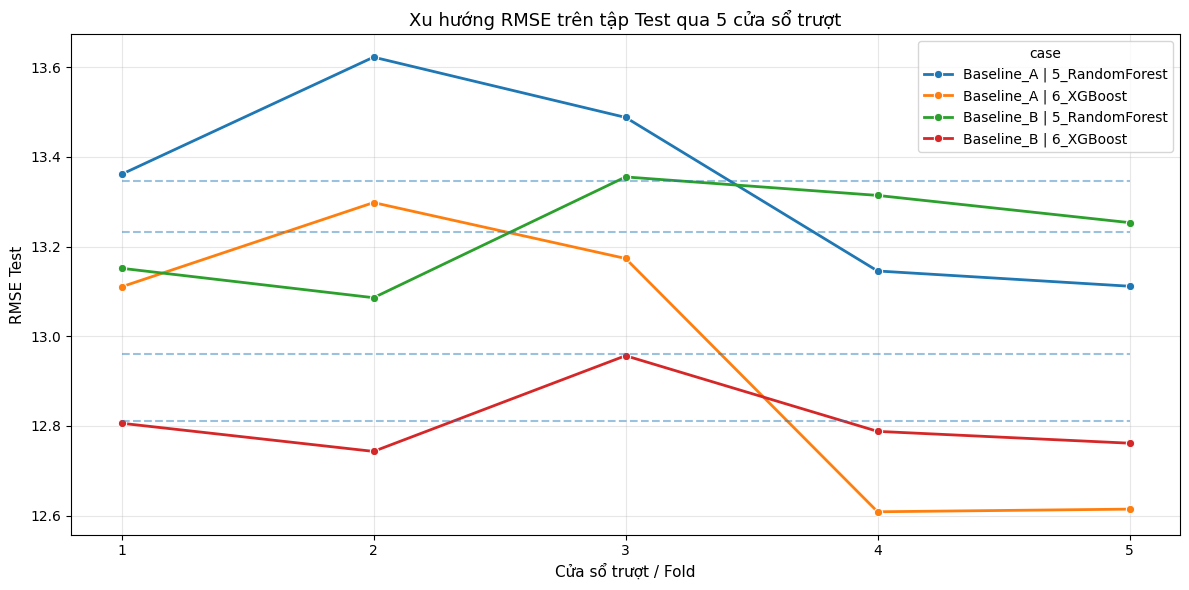

In [40]:
sliding_summary = stability.summarize_time_sliding(
    time_sliding_results,
    metric='RMSE',
    stable_cv_threshold=STABILITY_CONFIG['stable_cv_threshold'],
)
display(sliding_summary)

stability.plot_time_sliding_rmse(
    time_sliding_results,
    save_path=f"{CONFIG['images_dir']}/time_sliding_rmse.png",
)


### 9.3. Kết luận kiểm định ổn định

Diễn giải bảng `sliding_summary`: nếu `RMSE_cv_%` nhỏ hơn ngưỡng cấu hình (`stable_cv_threshold`, mặc định 10%) và đường RMSE qua 5 fold gần như nằm ngang, có thể kết luận dữ liệu ổn định theo thời gian đối với bài toán dự báo flow. Nếu một fold tăng RMSE đột biến, cần kiểm tra giai đoạn thời gian tương ứng vì có thể xuất hiện biến động giao thông bất thường hoặc lỗi cảm biến.
